In [1]:
# S2 signal script
import sys
sys.path.append('/home/investigator/mariandbt/python/notebooks/modules')

from import_modules import *

import set_up as setup

In [2]:
path = '/home/investigator/mariandbt/python/data'
path = path + '/20240313_s2simulation'

In [3]:
sns_path = os.path.join(path, "ie/20240405_Next100_ie_s2_1.next.h5")
s2_table_path = os.path.join(path, "s2tab/20240405_s2_table.h5")
event_path = os.path.join(path, "bb/20240228_Next100_10ev_ELon_bb_1.next.h5") # 10 full bb w s2


# $\beta$ $\beta$ event

In [4]:
import s2_signal as s2sig

In [5]:
# ________________________________________________________________________________________________________________
# Global params
# ________________________________________________________________________________________________________________

n_panels = 18
n_sensors = 108

v_drift_EL = 2.5e-3 # [mm]/[ns] = 2.5 [mm]/[us]

n_bb_events_per_file = 1 # we're only gonna get the first event

list_of_bb_file_paths = [event_path]
n_bb_files = len(list_of_bb_file_paths)

# ________________________________________________________________________________________________________________

s2sig.set_global_parameters(globals(),
                            n_bb_files = n_bb_files,
                            n_bb_events_per_file = n_bb_events_per_file,
                            n_panels = n_panels,
                            n_sensors = n_sensors,
                            v_drift_EL = v_drift_EL,
                            geant4_t_binin_in_ns = 0.1,
                            samplin_rate_in_ns = 25
                           )

Global parameters set successfully :)


In [6]:
start, event, sensor = 0, 0, 202
start, bb_ie, prim_e = s2sig.find_bb_ie(event_path, start, event)

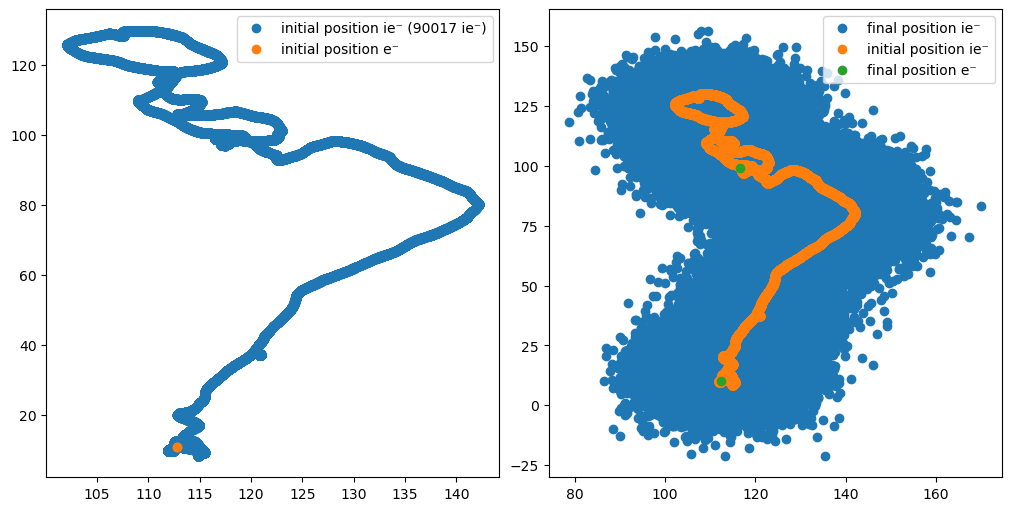

In [7]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,5), constrained_layout=True, sharex=False, sharey=False)

# Transfer the content from the original axes to the new subplot

ax[0].plot(bb_ie.initial_x, bb_ie.initial_y, 'o', label = f'initial position ie⁻ ({len(bb_ie)} ie⁻)')
ax[0].plot(prim_e.initial_x, prim_e.initial_y, 'o', label = 'initial position e⁻')
ax[0].legend()

ax[1].plot(bb_ie.final_x, bb_ie.final_y, 'o', label = 'final position ie⁻')
ax[1].plot(bb_ie.initial_x, bb_ie.initial_y, 'o', label = 'initial position ie⁻')
ax[1].plot(prim_e.final_x, prim_e.final_y, 'o', label = 'final position e⁻')
ax[1].legend()

/home/investigator/miniconda3/envs/IC-3.8-2022-04-13/lib/python3.8/site-packages/pandas/io/pytables.py:3523: IncompatibilityWarning: 
where criteria is being ignored as this version [0.0.0] is too old (or
not-defined), read the file in and write it out to a new file to upgrade (with
the copy_to method)

  warnings.warn(ws, IncompatibilityWarning)


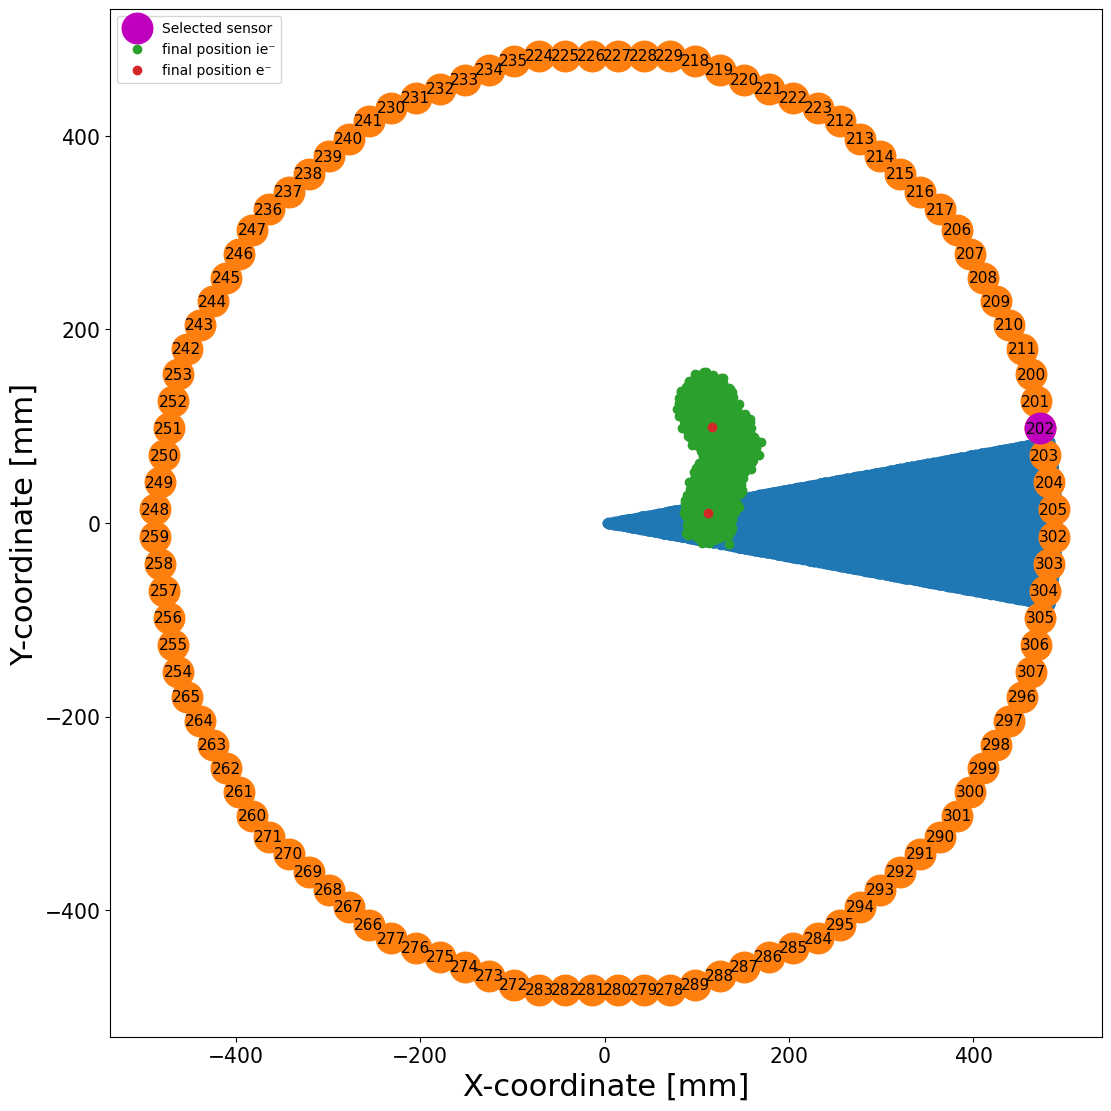

In [8]:
ax = setup.print_sens_geometry(sns_path, sensor)

ax.plot(bb_ie.final_x, bb_ie.final_y, 'o', label = 'final position ie⁻')
ax.plot(prim_e.final_x, prim_e.final_y, 'o', label = 'final position e⁻')

ax.legend(loc= 'upper left')

# Signal waveform

In [9]:
s2_table = setup.read_s2_table(s2_table_path)

In [10]:
s2_signal_path_not_shaped = os.path.join(path, 's2signals/20240521_TEST_bb0nu_1ev_ELoff_s2_signal_20240405s2table.h5')

# s2sig.create_s2_signal(s2_table, sns_path, list_of_bb_file_paths, s2_signal_path_not_shaped)

In [11]:
# setup.check_h5(s2_signal_path_not_shaped)

In [12]:
import s2_hists as s2hist

In [13]:
ev = f'{event}'
sens = f'sens_{sensor}'

# Open the HDF5 file in read mode
with h5py.File(s2_signal_path_not_shaped, 'r') as file:

    # Get the group corresponding to the current key
    event_group = file[ev]

    # Get and print the value corresponding to the current subkey
    signal        = event_group[sens]
    s2_not_shaped = np.array(signal['s2_in_pes']) # [pes]
    t_not_shaped  = np.array(signal['time_in_ns'])*1e-3 # [us]

In [14]:
bin_width_in_us = 1 # [us]
# bin_width_in_us = 25e-3 # [us]

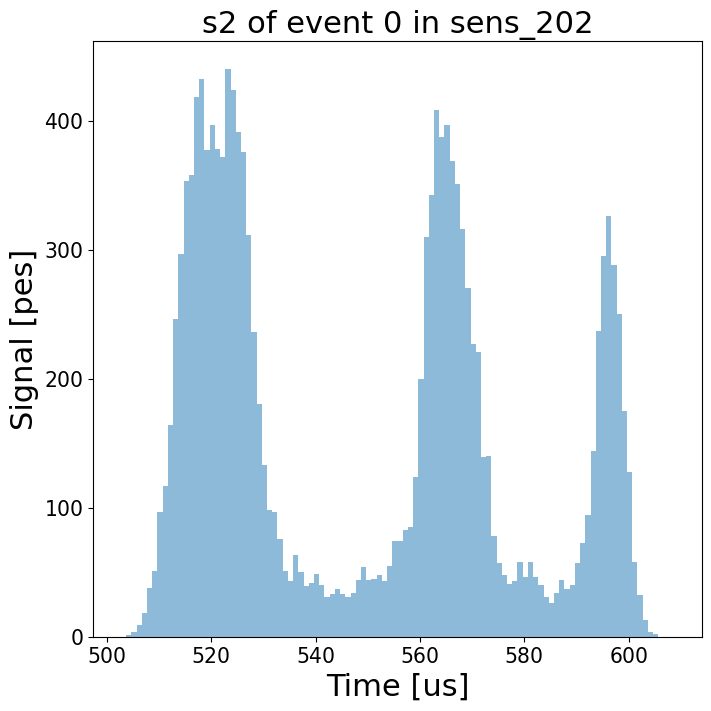

In [15]:

s2_signal, t_in_us, ax = s2hist.print_offline_s2waveform_v2(s2_signal_path_not_shaped, event, sensor, 
                                                            bin_width_in_us = bin_width_in_us, 
                                                            new_figure = True, 
                                                            comment = r'NOT SHAPED (108 sens)')


# Shapin and samplin

In [16]:
# ________________________________________________________________________________________________________________
# Global params
# ________________________________________________________________________________________________________________

shapin_tau_in_ns   = 155 # [ns]
# shapin_tau_in_ns   = 20  # [ns]
samplin_rate_in_ns = 25  # [ns]
t_binin_in_ns      = 1   # [ns]

# ________________________________________________________________________________________________________________

# s2sig.shapin_and_samplin(s2_signal_path_not_shaped, shapin_tau_in_ns, samplin_rate_in_ns, t_binin_in_ns)

s2_signal_shaped_sampled_path = s2_signal_path_not_shaped.replace('_s2_signal_', f'_s2_signal_shaped{shapin_tau_in_ns}ns_sampled{samplin_rate_in_ns}ns_')


In [17]:
# setup.check_h5(s2_signal_shaped_sampled_path)

In [18]:
# samplin_rate_in_us = 1
samplin_rate_in_us = 25e-3


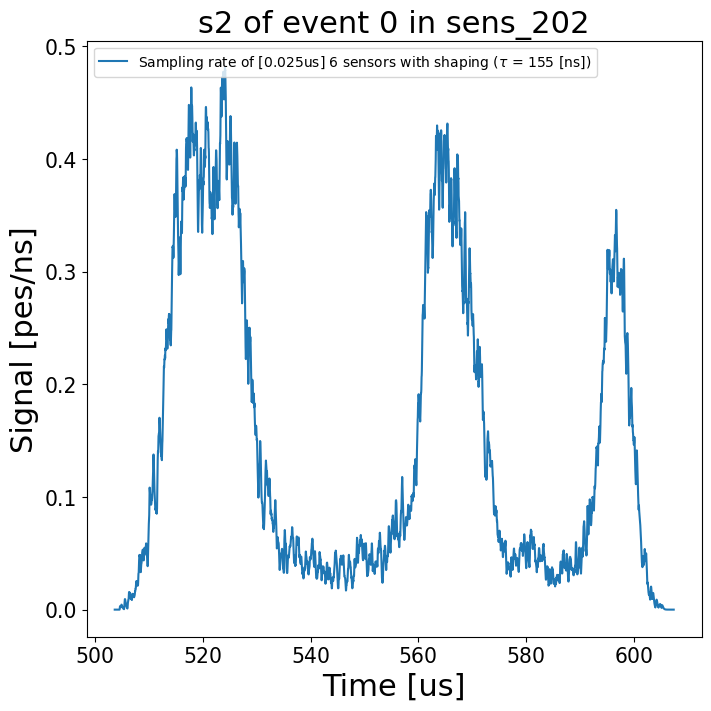

In [19]:

s2_shaped_sampled, t_in_us, ax = s2hist.print_offline_s2waveform(s2_signal_shaped_sampled_path, event, sensor, 
                                                                 t0_in_us = t_not_shaped.min(), 
                                                                 samplin_rate_in_us = samplin_rate_in_us, 
                                                                 new_figure = True, 
                                                                 comment = fr'6 sensors with shaping ($\tau$ = {shapin_tau_in_ns} [ns])')
ax.set_ylabel('Signal [pes/ns]')

ax.legend(loc = 'upper left')

In [20]:
impedance_in_ohm = 50
s2_shaped_sampled_in_mV = s2sig.conversion_to_mV(s2_shaped_sampled, impedance_in_ohm)

(0.0, 17.0)

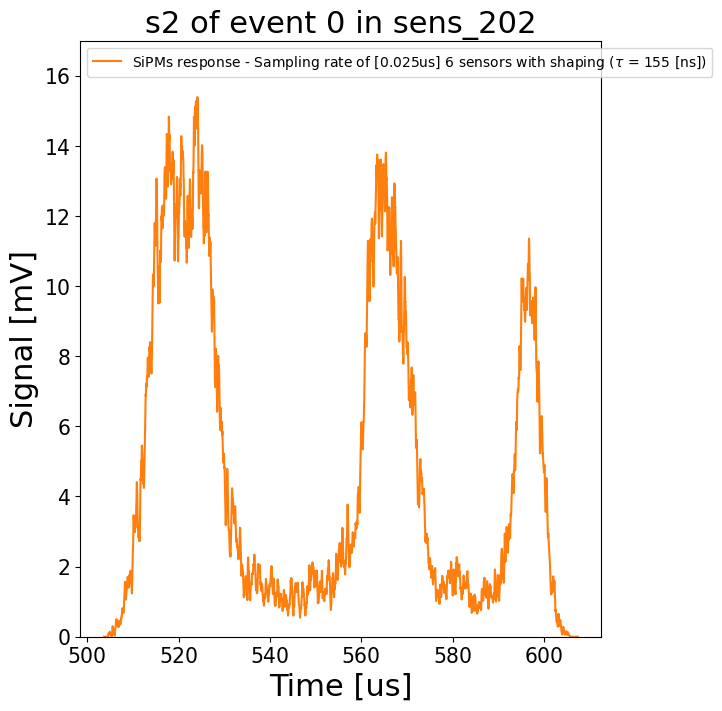

In [21]:
s2_shaped_sampled, t_in_us, ax = s2hist.print_offline_s2waveform(s2_signal_shaped_sampled_path, event, sensor, 
                                                                 t0_in_us = t_not_shaped.min(), 
                                                                 samplin_rate_in_us = samplin_rate_in_us, 
                                                                 new_figure = True, 
                                                                 comment = fr'6 sensors with shaping ($\tau$ = {shapin_tau_in_ns} [ns])')


ax.plot(t_in_us, s2_shaped_sampled_in_mV, label = 'SiPMs response')
ax.set_ylabel('Signal [mV]')

# Access the lines from the ax object
lines = ax.get_lines()

# Remove the second line (cosine wave)
lines[0].remove()

# Store the legend of the line to be removed
line0_legend = lines[0].get_label()
line1_legend = lines[1].get_label()

# Update the remaining line's legend
lines[1].set_label(f'{line1_legend} - {line0_legend}')

ax.legend(loc = 'upper left')

ax.set_ylim(0, 17)



In [22]:
np.trapz(y = s2_shaped_sampled, x = t_in_us*1e3)


15217.781267492981

In [23]:
s2_signal.sum()

15218.0

# $\beta$ $\beta$ event: nexus vs offline

In [24]:

import s2_simulation as s2bb
from s2_simulation import unit

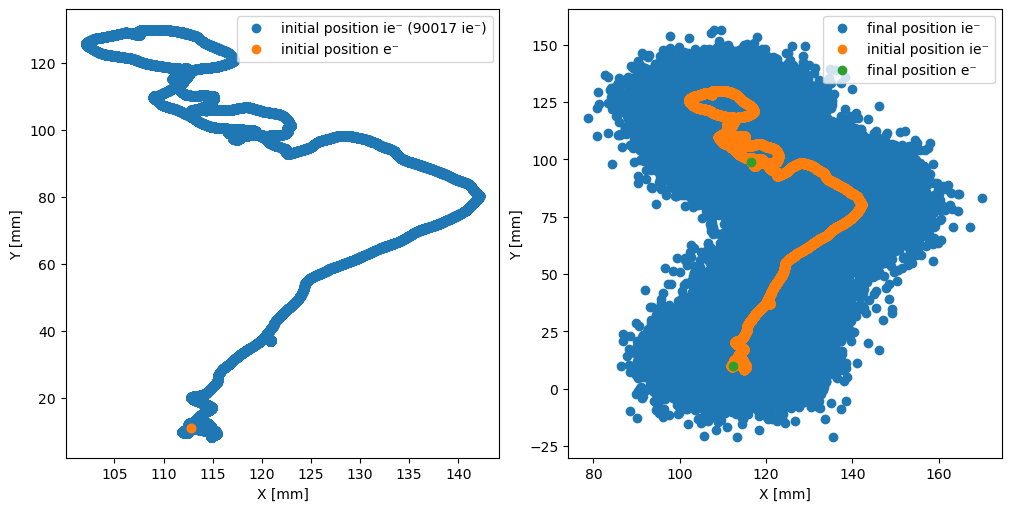

In [25]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,5), constrained_layout=True, sharex=False, sharey=False)

# Transfer the content from the original axes to the new subplot

ax[0].plot(bb_ie.initial_x, bb_ie.initial_y, 'o', label = f'initial position ie⁻ ({len(bb_ie)} ie⁻)')
ax[0].plot(prim_e.initial_x, prim_e.initial_y, 'o', label = 'initial position e⁻')
ax[0].set_xlabel('X [mm]')
ax[0].set_ylabel('Y [mm]')
ax[0].legend()

ax[1].plot(bb_ie.final_x, bb_ie.final_y, 'o', label = 'final position ie⁻')
ax[1].plot(bb_ie.initial_x, bb_ie.initial_y, 'o', label = 'initial position ie⁻')
ax[1].plot(prim_e.final_x, prim_e.final_y, 'o', label = 'final position e⁻')
ax[1].set_xlabel('X [mm]')
ax[1].set_ylabel('Y [mm]')
ax[1].legend()

In [26]:
# Create TPC
TPC     = s2bb.HPGXeTPC()
TPC.SetActiveDriftVelocity()
TPC.SetRecombinationFactor()
TPC.SetElectronLifetime()
TPC.SetActiveLongDiffusion()
TPC.SetActiveTransDiffusion()
TPC.SetEL()
TPC.SetSensors(sns_path)

/home/investigator/miniconda3/envs/IC-3.8-2022-04-13/lib/python3.8/site-packages/pandas/io/pytables.py:3523: IncompatibilityWarning: 
where criteria is being ignored as this version [0.0.0] is too old (or
not-defined), read the file in and write it out to a new file to upgrade (with
the copy_to method)

  warnings.warn(ws, IncompatibilityWarning)


In [27]:
nexusEvent = s2bb.nexusEvent(event_path, event)
nexusEvent.AddDriftAndDiffusion(TPC)

In [28]:
x, y, t = nexusEvent.ElectronsFinalX, nexusEvent.ElectronsFinalY, nexusEvent.ElectronsMeasurementTime


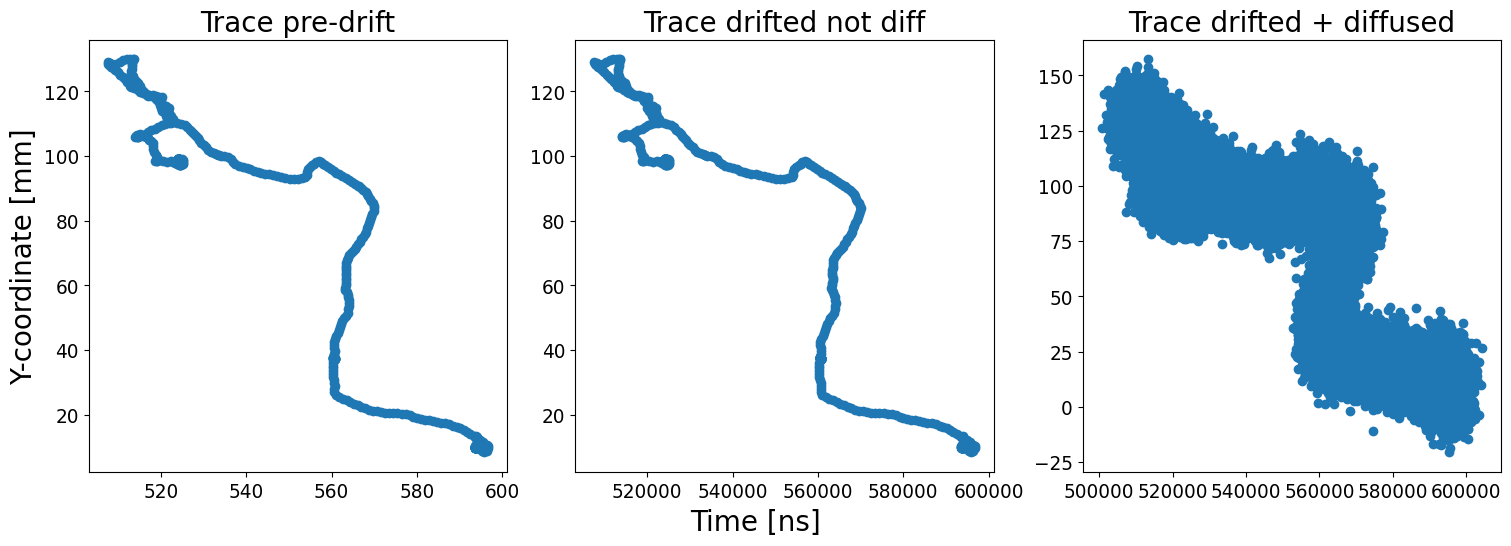

In [29]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15,5), constrained_layout=True, sharex=False, sharey=False)
font_size = 20

ax = ax.ravel()
z_not_drift_not_diff  = nexusEvent.HitsZ
t_yes_drift_not_diff  = nexusEvent.HitsTime + nexusEvent.DriftTime
y_not_drift_not_diff  = nexusEvent.HitsY # doesn't change with drift tho

ax[0].plot(z_not_drift_not_diff.magnitude, y_not_drift_not_diff.magnitude, 'o')
ax[1].plot(t_yes_drift_not_diff.magnitude, y_not_drift_not_diff.magnitude, 'o')
ax[2].plot(t.magnitude, y.magnitude, 'o')

fig.text(0.5, -0.05, f'Time [{t.units:~}]', ha='center', fontsize = font_size)
ax[0].set_ylabel(f'Y-coordinate [{y.units:~}]', fontsize = font_size)

for axx, title in zip(ax, ['Trace pre-drift', 'Trace drifted not diff', 'Trace drifted + diffused']):
    axx.tick_params(axis='both', which = 'both', labelsize = font_size*2/3)
    axx.set_title(title, fontsize = font_size)

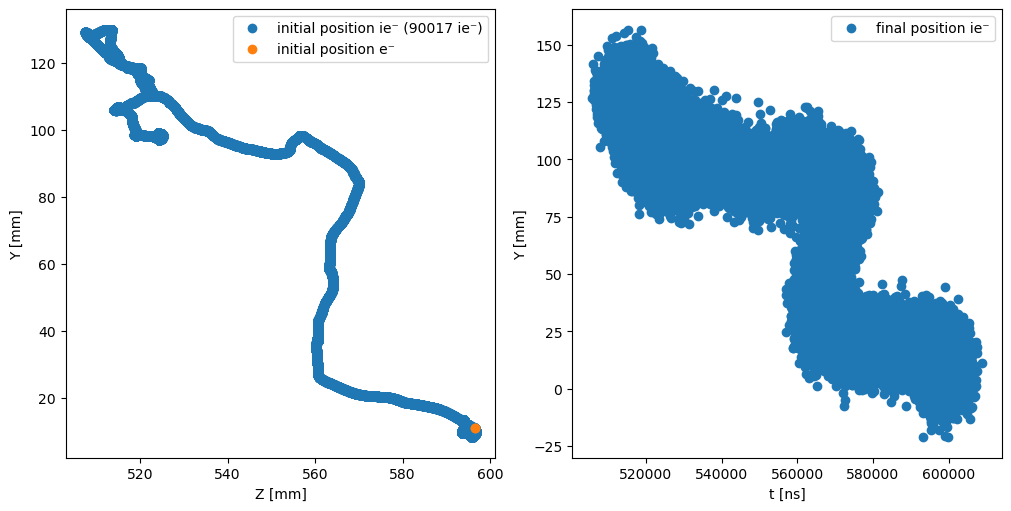

In [30]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,5), constrained_layout=True, sharex=False, sharey=False)

# Transfer the content from the original axes to the new subplot

ax[0].plot(bb_ie.initial_z, bb_ie.initial_y, 'o', label = f'initial position ie⁻ ({len(bb_ie)} ie⁻)')
ax[0].plot(prim_e.initial_z, prim_e.initial_y, 'o', label = 'initial position e⁻')

ax[0].set_xlabel('Z [mm]')
ax[0].set_ylabel('Y [mm]')
ax[0].legend()

ax[1].plot(bb_ie.final_t, bb_ie.final_y, 'o', label = 'final position ie⁻')
# ax[1].plot(bb_ie.initial_t, bb_ie.initial_y, 'o', label = 'initial position ie⁻')
# ax[1].plot(prim_e.final_t, prim_e.final_y, 'o', label = 'final position e⁻')

ax[1].set_xlabel('t [ns]')
ax[1].set_ylabel('Y [mm]')
ax[1].legend()

# $\beta$ $\beta$ signal reconstruction: offline

In [2]:
# S2 signal script
import sys
sys.path.append('/home/investigator/mariandbt/python/notebooks/modules')

from import_modules import *

import set_up as setup

In [32]:
path = '/home/investigator/mariandbt/python/data'
path = path + '/20240313_s2simulation'

In [33]:
sns_path = os.path.join(path, "ie/20240405_Next100_ie_s2_1.next.h5")
s2_table_path = os.path.join(path, "s2tab/20240405_s2_table.h5")
event_path = os.path.join(path, "bb/20240228_Next100_10ev_ELon_bb_1.next.h5") # 10 full bb w s2


In [34]:
import s2_simulation as s2sim
from s2_simulation import unit

In [35]:
event, sensor = 6, 285

In [36]:
# Create TPC
TPC     = s2sim.HPGXeTPC()
TPC.SetDefaults(sns_path)

Default parameters set succesfully :) TPC ready to use


/home/investigator/miniconda3/envs/IC-3.8-2022-04-13/lib/python3.8/site-packages/pandas/io/pytables.py:3523: IncompatibilityWarning: 
where criteria is being ignored as this version [0.0.0] is too old (or
not-defined), read the file in and write it out to a new file to upgrade (with
the copy_to method)

  warnings.warn(ws, IncompatibilityWarning)


In [37]:
nexusEvent = s2sim.nexusEvent(event_path, event)
nexusEvent.AddDriftAndDiffusion(TPC)

In [38]:
s2table = s2sim.s2Table(s2_table_path)

In [39]:
# %%timeit # (~4mins)
s2_signal = s2sim.s2Signal(s2table, TPC, nexusEvent)

In [40]:
# %%timeit # (~4mins/sensor for t_bin = 0.1ns; 41s in total for t_bin = 1ns)
s2_signal.AddShapinAndSamplin(samplin_rate = 25*unit.ns, t_binin = 1*unit.ns)

/home/investigator/mariandbt/python/notebooks/modules/s2_simulation.py:321: RuntimeWarning: overflow encountered in multiply
  signal = (rise_term * decay_term)


14749.0

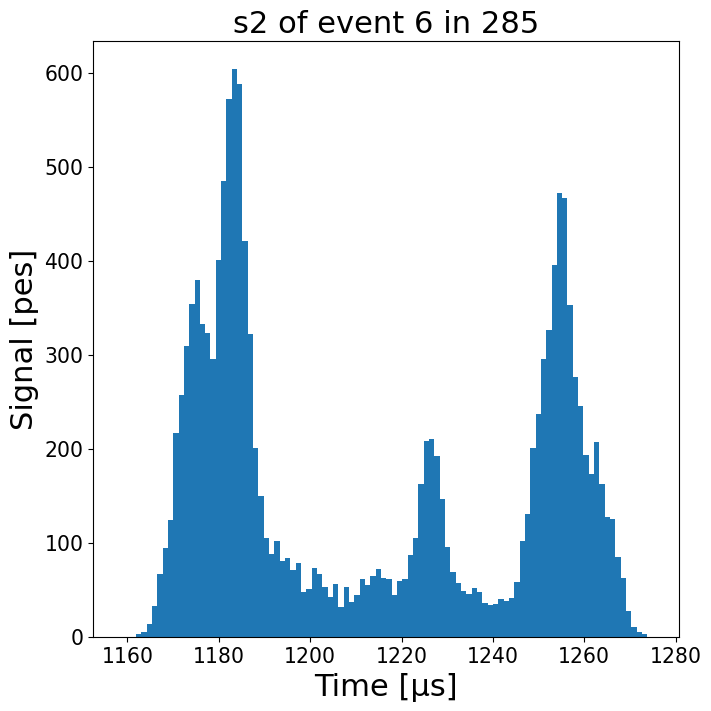

In [41]:
t, waveform, ax = s2_signal.PrintWaveform(sensor, shaped_and_sampled = False)
# ax.legend();
waveform.sum()

472071.55867915624

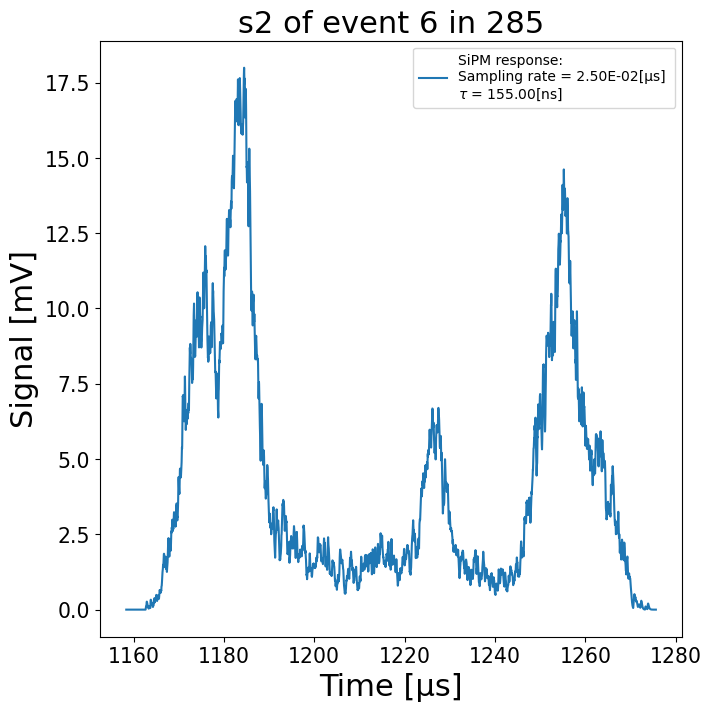

In [43]:
t, waveform, ax = s2_signal.PrintWaveform(sensor, units = 'mV')
ax.legend()
np.trapz(y = waveform, x = t.to(unit.ns).magnitude)

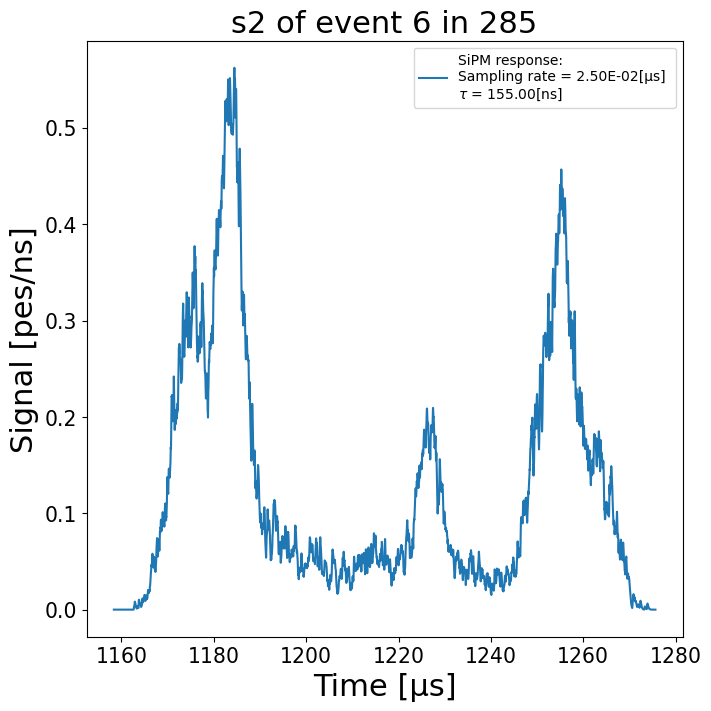

In [45]:
t, waveform, ax = s2_signal.PrintWaveform(sensor, units = 'pes/ns')
ax.legend()


In [204]:
event_path2 = os.path.join(path, "bb/20240306_Next100_200ev_ELoff_bb_1.next.h5") # 200 evs w/o s2

nexusEvent = s2sim.nexusEvent(event_path2, 0)
nexusEvent.AddDriftAndDiffusion(TPC)

In [205]:
hit_e   = nexusEvent.HitsEnergy

t_hit   = nexusEvent.HitsTime # [ns]
x_hit   = nexusEvent.HitsX # [mm]
y_hit   = nexusEvent.HitsY # [mm]
z_hit   = nexusEvent.HitsZ # [mm]
z_EL    = TPC.StartELPositionZ # [mm] Z position towards which the e⁻ drift 

# Drift
z_drift = np.fabs(z_EL - z_hit) # [mm]
v_drift = TPC.ActiveDriftVelocity
t_drift = (z_drift/v_drift).to(unit.ns)

t_measurement = t_hit + t_drift # After drift

recombi_prob    = 1 - TPC.RecombinationFactor
lifetime_prob   = np.exp(-t_drift/TPC.ElectronLifetime).magnitude

ionization_energy   = TPC.HPGXeIonization
fano_factor         = TPC.HPGXeFano

n_ie    = (hit_e/ionization_energy).magnitude
sigma   = np.sqrt(n_ie*fano_factor)

# Fano factor correction
n_ie    = np.random.normal(loc = n_ie*recombi_prob, scale = sigma) # recombination
n_ie    = np.random.normal(loc = n_ie*lifetime_prob, scale = sigma) # lifetime correction


In [182]:
(hit_e/ionization_energy).magnitude[n_ie < 0]

array([0.56263477], dtype=float32)

In [183]:
n_ie[n_ie < 0]

array([-0.78478961])

In [184]:
np.vectorize(int)(n_ie[n_ie < 0])

array([0])

In [80]:
n_ie[n_ie < 0] = 0

In [81]:
n_ie[n_ie < 0]

array([], dtype=float64)

In [190]:
n_ie = 0.2
sigma   = np.sqrt(n_ie*fano_factor)

# Fano factor correction
n_ie    = np.random.normal(loc = n_ie*recombi_prob, scale = sigma) # recombination
n_ie    = np.random.normal(loc = n_ie*lifetime_prob, scale = sigma) # lifetime correction

n_ie[n_ie < 0]

array([-0.04495684, -0.00757627, -0.02528672, -0.03203391, -0.11850774,
       -0.01594829, -0.19864725, -0.05077278, -0.10375341, -0.00303506,
       -0.00798273, -0.03116177, -0.07018327, -0.07851883, -0.09597888,
       -0.0905171 , -0.02212551, -0.32013891, -0.06010208, -0.00257192,
       -0.00059055, -0.05123584, -0.09337761, -0.08284338, -0.09151126,
       -0.00245018, -0.00094122, -0.00096097, -0.00815389, -0.10641672,
       -0.26762942, -0.1369701 ])

In [195]:
nexusEvent.ElectronsMeasurementTime[0]

594640.8213168582 <Unit('nanosecond')>

In [206]:
t = nexusEvent.ElectronsMeasurementTime
t0 = nexusEvent.ElectronsMeasurementTime.mean()
tau = 155 *unit.ns
rise_time = 1

((1 - np.exp(-(t - t0) / (tau * rise_time))) * (np.exp(-(t - t0) / tau))).magnitude

array([1.35524004e-17, 1.34774901e-11, 3.75516087e-13, ...,
       8.77673606e-34, 2.07672682e-25, 1.77003441e-37])

In [207]:
print('This event is empty... Try another, this one won\'t take you far :(')


This event is empty... Try another, this one won't take you far :(


In [27]:
def error_poisson(k, N):
    error = np.sqrt(k**2*(N+k)/(N**3))
#     error = np.sqrt(k*(1-k/N))/N
    return error
    
def error_ratio(numer, numer_err, denom, denom_err):
    error = np.sqrt((numer_err/numer)**2 + (denom_err/denom)**2)
    return error
    

In [28]:
Ntot = 1e4

detected1mm = np.array([1097, 268, 107, 71, 39, 25])
detected2mm = np.array([1227, 283, 126, 59, 43, 20])
dist = np.array([1, 10, 20, 30, 40, 50])

eff1 = detected1mm/Ntot
eff2 = detected2mm/Ntot

err1 = error_poisson(detected1mm, Ntot)
err2 = error_poisson(detected2mm, Ntot)

ratio = eff1/eff2
ratio_err = error_ratio(eff1, err1, eff2, err2)


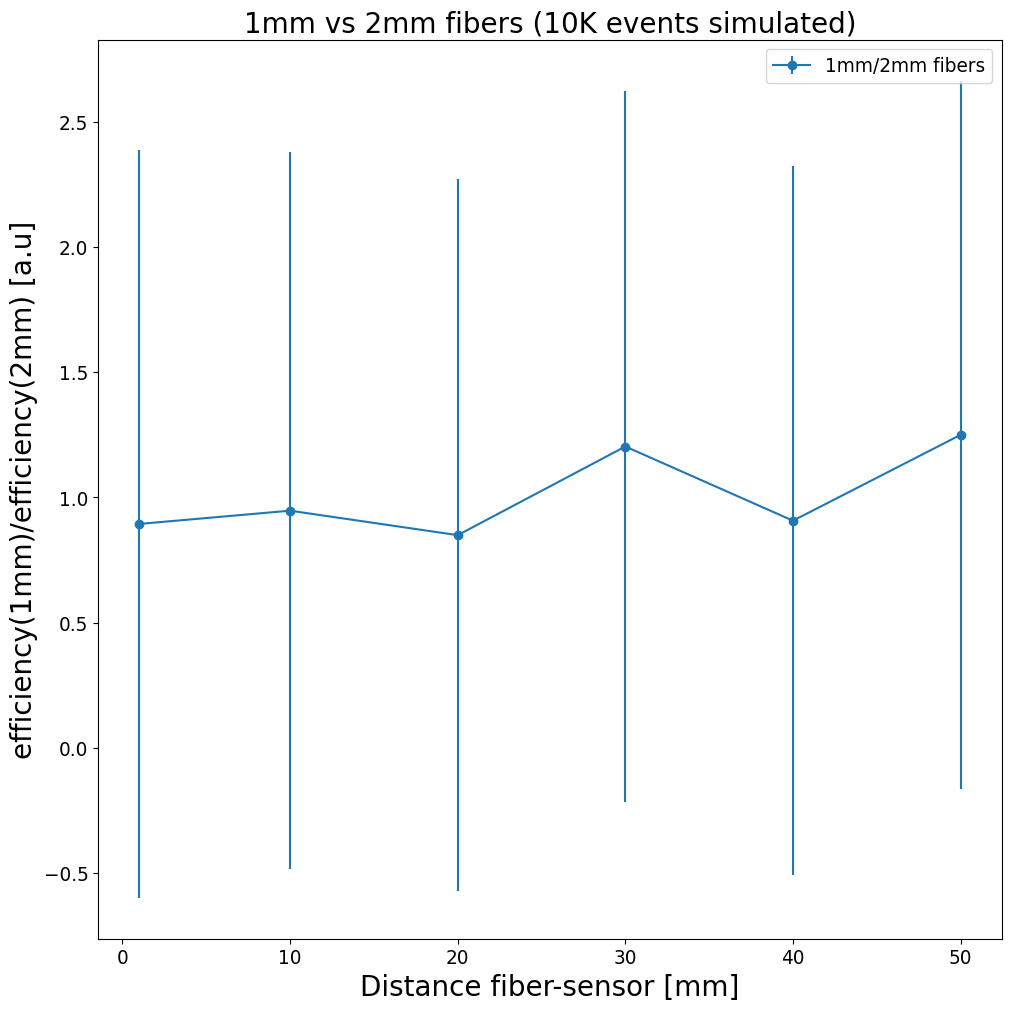

In [29]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,10), constrained_layout=True, sharex=False, sharey=False)

font_size = 20

# ax.errorbar(dist, eff1, yerr=err1, fmt='-o', label='1mm fibers')
# ax.errorbar(dist, eff2, yerr=err2, fmt='-o', label='2mm fibers')
ax.errorbar(dist, ratio, yerr=ratio_err, fmt='-o', label='1mm/2mm fibers')


ax.set_title('1mm vs 2mm fibers (10K events simulated)', fontsize = font_size);
ax.set_xlabel('Distance fiber-sensor [mm]', fontsize = font_size);
ax.set_ylabel('efficiency(1mm)/efficiency(2mm) [a.u]', fontsize = font_size);
ax.tick_params(axis='both', labelsize = font_size*2/3)
ax.legend(fontsize = font_size*2/3)

In [30]:
aa = {}
aa['bb'] = [1, 2, 3]
aa['cc'] = [1, 2]

In [32]:
len(aa.values())

2

In [1]:
# S2 signal script
import sys
sys.path.append('/home/investigator/mariandbt/python/notebooks/modules')

from import_modules import *

import set_up as setup
import s2_simulation as s2sim

In [2]:
path = '/home/investigator/mariandbt/python/data'
path = path + '/20240627_SinglePhoton'

In [3]:
sp_path = os.path.join(path, "SaveOnEvent_ALL_20240523152859512.csv")


In [4]:
df = pd.read_csv(sp_path, skiprows=15)
# df = pd.read_csv(sp_path, skiprows=5)


In [66]:
df.TIME[0] - df.TIME[1], df.TIME[1] - df.TIME[2]

(-1.5999999999999614e-10, -1.5999999999999614e-10)

In [6]:
df_area = np.trapz(x = df.TIME, y = df.CH1)

In [7]:
df_area

8.856319999999998e-09

In [8]:
df_area, df.CH1.sum()

(8.856319999999998e-09, 55.352)

In [10]:
generic_sipm_response = s2sim.ResponseSiPM(df_area, df.TIME, 0, 25e-9, 25e-9)

In [28]:
tau = 25 # [ns]
rise = tau # [ns]


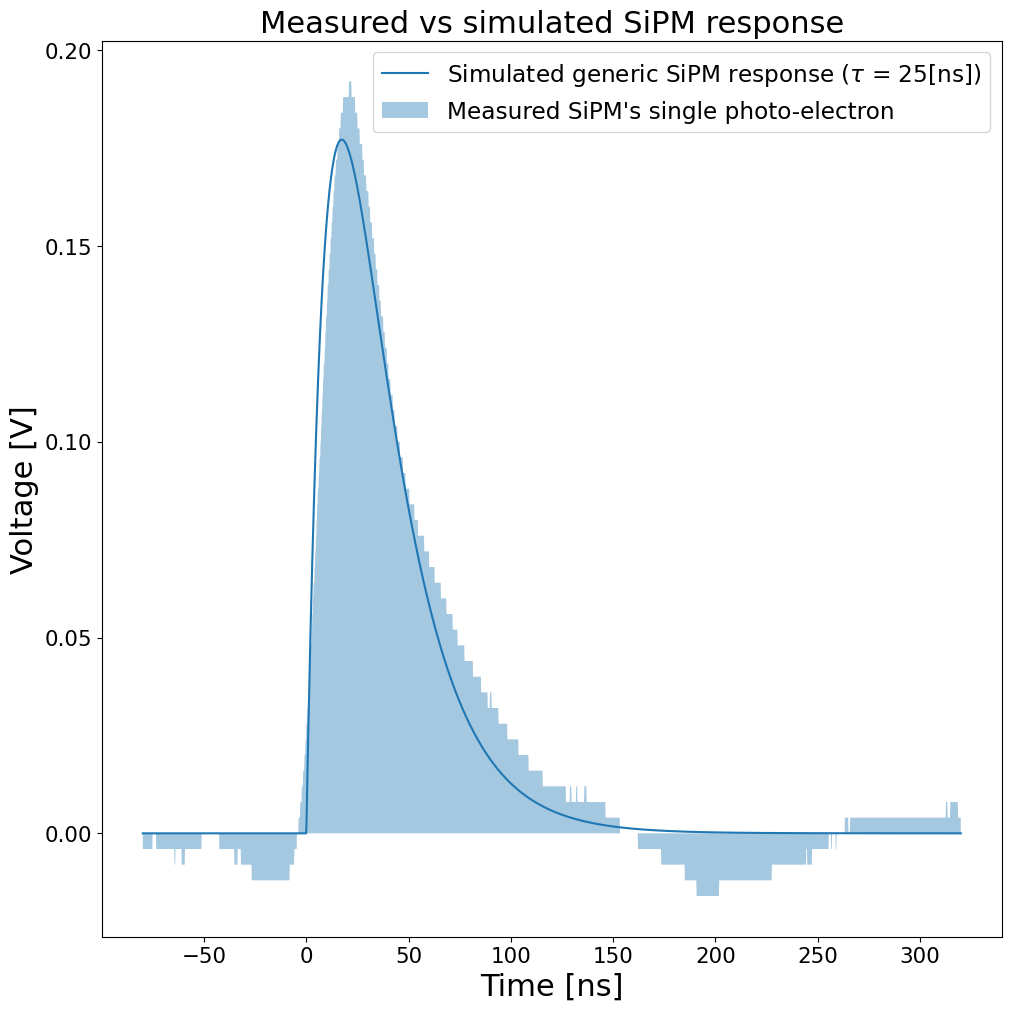

In [29]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize=(10, 10), constrained_layout=True)

font_size = 22

t = df.TIME*1e9 # [ns]
wvf = df.CH1 # [V]

# ax.plot(df.TIME, df.CH1)
ax.fill_between(t, wvf, alpha = 0.4, label = f'Measured SiPM\'s single photo-electron') 
df_area = np.trapz(x = t, y = wvf)

generic_sipm_response = s2sim.ResponseSiPM(df_area, t, 0, rise, tau)
ax.plot(t, generic_sipm_response, label = fr'Simulated generic SiPM response ($\tau$ = {tau}[ns])')

ax.legend(fontsize = 0.758*font_size)

# ax.set_ylim(-0.02, 0.22)
ax.tick_params(axis='both', labelsize = font_size*0.7)

ax.set_title(f'Measured vs simulated SiPM response', fontsize = font_size);
ax.set_xlabel(f'Time [ns]', fontsize = font_size);
ax.set_ylabel('Voltage [V]', fontsize = font_size);

In [15]:
def model_function(t, t0, rise, tau):
    return s2sim.ResponseSiPM(df_area, t, t0, rise, tau)

In [16]:
from scipy.optimize import curve_fit

In [21]:
t = df.TIME*1e9 # [ns]
wvf = df.CH1 # [V]
df_area = np.trapz(x = t, y = wvf)

# Sample data
waveform_time = t  # Your waveform_time data here
measured_data = wvf  # Your measured data to fit

# Initial guesses for the parameters
initial_time_guess = 0 # [ns]
decay_time_guess = 25 # [ns]
rise_time_guess = 12 # [ns]
initial_guess = [initial_time_guess, rise_time_guess, decay_time_guess]

# Perform the fit
params, covariance = curve_fit(model_function, waveform_time, measured_data, p0=initial_guess)

# Extract the optimized parameters
opt_t0, opt_rise, opt_tau = params

In [22]:
opt_t0, opt_rise, opt_tau

(1.0112813732499946, 49.7467926110456, 22.740059392040187)

In [23]:
tau = opt_tau # [ns]
rise = opt_rise # [ns]
t0 = opt_t0

In [35]:
tau = 28
rise = 12

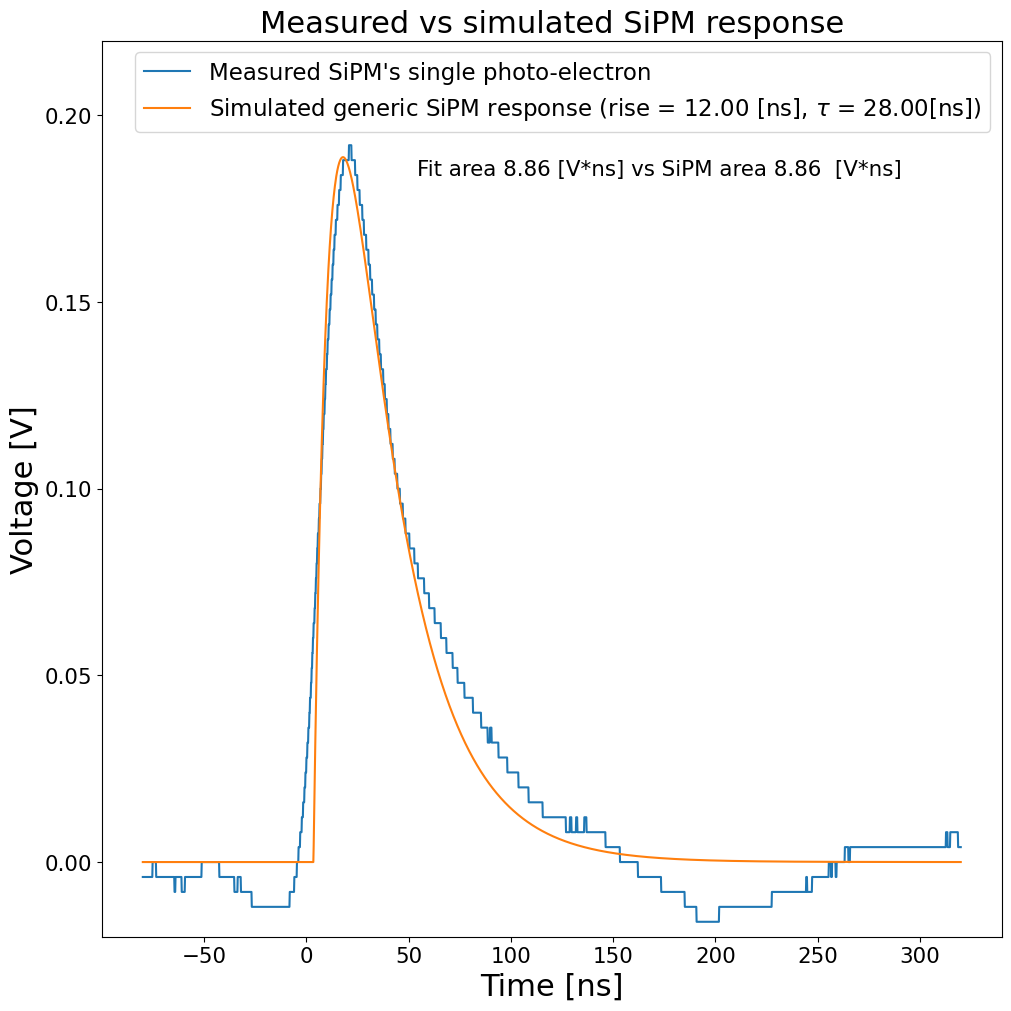

In [36]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize=(10, 10), constrained_layout=True)

font_size = 22

t = df.TIME*1e9 # [ns]
wvf = df.CH1 # [V]
df_area = np.trapz(x = t, y = wvf)

# ax.plot(df.TIME, df.CH1)
ax.plot(t, wvf, alpha = 1, label = f'Measured SiPM\'s single photo-electron') 
df_area = np.trapz(x = t, y = wvf)

generic_sipm_response = s2sim.ResponseSiPM(df_area, t, t0, rise, tau)
ax.plot(t, generic_sipm_response, 
        label = fr'Simulated generic SiPM response (rise = {rise:.2f} [ns], $\tau$ = {tau:.2f}[ns])')

sipm_area = df_area
fit_area  = np.trapz(x = t, y = generic_sipm_response)
ax.text(0.35, .85, f'Fit area {fit_area:.2f} [V*ns] vs SiPM area {sipm_area:.2f}  [V*ns]',
        transform=ax.transAxes, 
        fontsize=0.7*font_size, bbox=dict(facecolor='1.', edgecolor='none', pad=3.0))

ax.legend(fontsize = 0.75*font_size)

ax.set_ylim(-0.02, 0.22)
ax.tick_params(axis='both', labelsize = font_size*0.7)

ax.set_title(f'Measured vs simulated SiPM response', fontsize = font_size);
ax.set_xlabel(f'Time [ns]', fontsize = font_size);
ax.set_ylabel('Voltage [V]', fontsize = font_size);

In [30]:
def gaussian(t, mu, sigma):
    """Define a Gaussian function."""
    return (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((t - mu) / sigma) ** 2)

def convolution_model(t, t0, rise, tau, mu, sigma):
    """Convolution between s2sim.ResponseSiPM and a Gaussian."""
    dt = t[1] - t[0]  # Assuming uniform spacing in t
    response = s2sim.ResponseSiPM(df_area, t, t0, rise, tau)
    gauss = gaussian(t, mu, sigma)
    
    # Perform convolution
    convolved = np.convolve(response, gauss, mode='same')*dt
    return convolved

def fit_function(t, t0, rise, tau, mu, sigma):
    """Function to fit to the data."""
    return convolution_model(t, t0, rise, tau, mu, sigma)


In [31]:
t = df.TIME*1e9 # [ns]
wvf = df.CH1 # [V]
df_area = np.trapz(x = t, y = wvf)

# Sample data
waveform_time = t  # Your waveform_time data here
measured_data = wvf  # Your measured data to fit

# Initial guesses for the parameters
initial_time_guess = 1 # [ns]
decay_time_guess   = 25 # [ns]
rise_time_guess    = 2*decay_time_guess
mu_guess           = 120
sigma_guess        = 5 # [ns]
initial_guess = [initial_time_guess, rise_time_guess, decay_time_guess, mu_guess, sigma_guess]

# Perform the fit
params, covariance = curve_fit(fit_function, waveform_time, measured_data, p0=initial_guess)

# Extract the optimized parameters
opt_t0, opt_rise, opt_tau, opt_mu, opt_sigma = params

In [32]:
opt_t0, opt_rise, opt_tau, opt_mu, opt_sigma

(3.484436934385469,
 12.370080842453829,
 28.012534989230527,
 119.71570837609752,
 4.76769201997255)

In [33]:
tau = opt_tau # [ns]
rise = opt_rise # [ns]
t0 = opt_t0
mu = opt_mu
sigma = opt_sigma

In [112]:
tau = 28 # [ns]
rise = 12 # [ns]
t0 = 5
mu = 120
sigma = 5

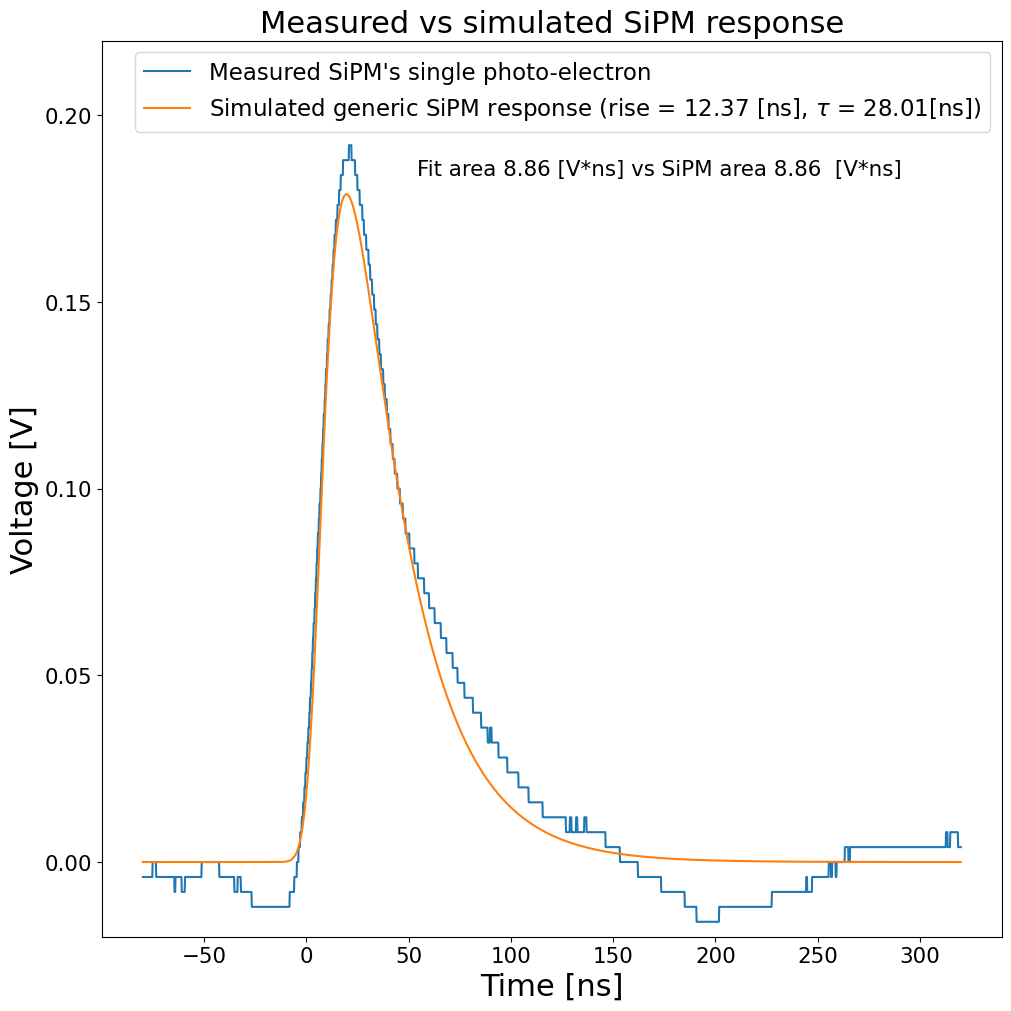

In [14]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize=(10, 10), constrained_layout=True)

font_size = 22

t = df.TIME*1e9 # [ns]
wvf = df.CH1 # [V]

# ax.plot(df.TIME, df.CH1)
ax.plot(t, wvf, alpha = 1, label = f'Measured SiPM\'s single photo-electron') 
df_area = np.trapz(x = t, y = wvf)

generic_sipm_response = fit_function(t, t0, rise, tau, mu, sigma)
ax.plot(t, generic_sipm_response, 
        label = fr'Simulated generic SiPM response (rise = {rise:.2f} [ns], $\tau$ = {tau:.2f}[ns])')

sipm_area = df_area
fit_area  = np.trapz(x = t, y = generic_sipm_response)
ax.text(0.35, .85, f'Fit area {fit_area:.2f} [V*ns] vs SiPM area {sipm_area:.2f}  [V*ns]',
        transform=ax.transAxes, 
        fontsize=0.7*font_size, bbox=dict(facecolor='1.', edgecolor='none', pad=3.0))

ax.legend(fontsize = 0.75*font_size)

ax.set_ylim(-0.02, 0.22)
ax.tick_params(axis='both', labelsize = font_size*0.7)

ax.set_title(f'Measured vs simulated SiPM response', fontsize = font_size);
ax.set_xlabel(f'Time [ns]', fontsize = font_size);
ax.set_ylabel('Voltage [V]', fontsize = font_size);

In [38]:

import s2_simulation as s2sim
from s2_simulation import unit

In [79]:
shapin_tau = 155 
shaping_rise = shapin_tau
t_binin = 0.1

In [81]:
time_data   = np.array([1, 500, 1000]) # [ns]

# for the s2 as deltas
tail_in_ns  = shapin_tau*30 # [ns]
bin_edges   = np.arange(time_data.min(), time_data.max() + tail_in_ns, t_binin)

# for the Shaping
bin_means               = (bin_edges[:-1] + bin_edges[1:])/2
generic_sipm_response   = s2sim.ResponseSiPM(1, bin_means, bin_means.mean(), shaping_rise, shapin_tau)

# s2 as deltas
s2_deltas, _    = np.histogram(time_data, bins=bin_edges, weights = [0, 1, 0])

# Shaping
s2_data_shaped          = np.convolve(s2_deltas, generic_sipm_response, mode='same')


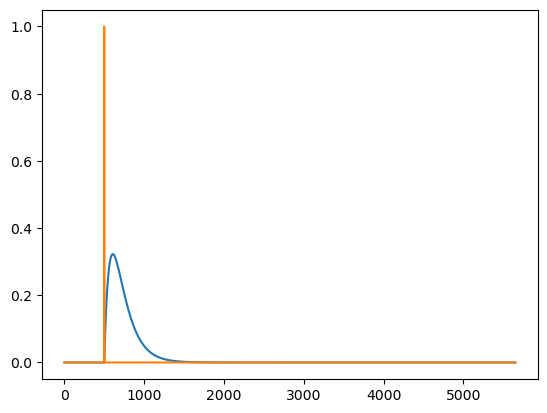

In [82]:
plt.plot(bin_means, 100*s2_data_shaped)
plt.plot(bin_means, s2_deltas)

In [89]:
s2_data_shaped.max()

0.003225806562068269

In [85]:
s2sim.ConvertTomV(s2_data_shaped).max()

0.10322580998618461

In [72]:
len(bin_edges)

46520

In [87]:
np.trapz(x = bin_means, y = s2_data_shaped)

1.0000000000078701

# $\beta$ $\beta$ waveform + diff: nexus vs offline

In [1]:
# S2 signal script
import sys
sys.path.append('/home/investigator/mariandbt/python/notebooks/modules')

from import_modules import *
import set_up as setup

import s2_simulation as s2sim
from s2_simulation import unit

In [2]:
path = '/home/investigator/mariandbt/python/data'
path = path + '/20240313_s2simulation'

In [3]:
sns_path = os.path.join(path, "ie/20240405_Next100_ie_s2_1.next.h5")
s2_table_path = os.path.join(path, "s2tab/20240405_s2_table.h5")
# event_path = os.path.join(path, "bb/20240228_Next100_10ev_ELon_bb_1.next.h5") # 10 full bb w s2 (ONLY 90 SENSs)
# event_path = os.path.join(path, "bb/20240710_Next100_3ev_ELon_bb_1.next.h5") # 3 full bb w s2
event_path = os.path.join(path, "bb/20240712_Next100_10ev_ELon_bb_1.next.h5") # 10 full bb w s2

# event_path = os.path.join(path, "Kr/20240724_Next100_10ev_ELoff_Kr_1.next.h5") 
# event_path = os.path.join(path, "Kr/20240828_Next100_10ev_ELon_Kr_1.next.h5") 


In [51]:
event, sensor = 6, 259


/home/investigator/miniconda3/envs/IC-3.8-2022-04-13/lib/python3.8/site-packages/pandas/io/pytables.py:3523: IncompatibilityWarning: 
where criteria is being ignored as this version [0.0.0] is too old (or
not-defined), read the file in and write it out to a new file to upgrade (with
the copy_to method)

  warnings.warn(ws, IncompatibilityWarning)


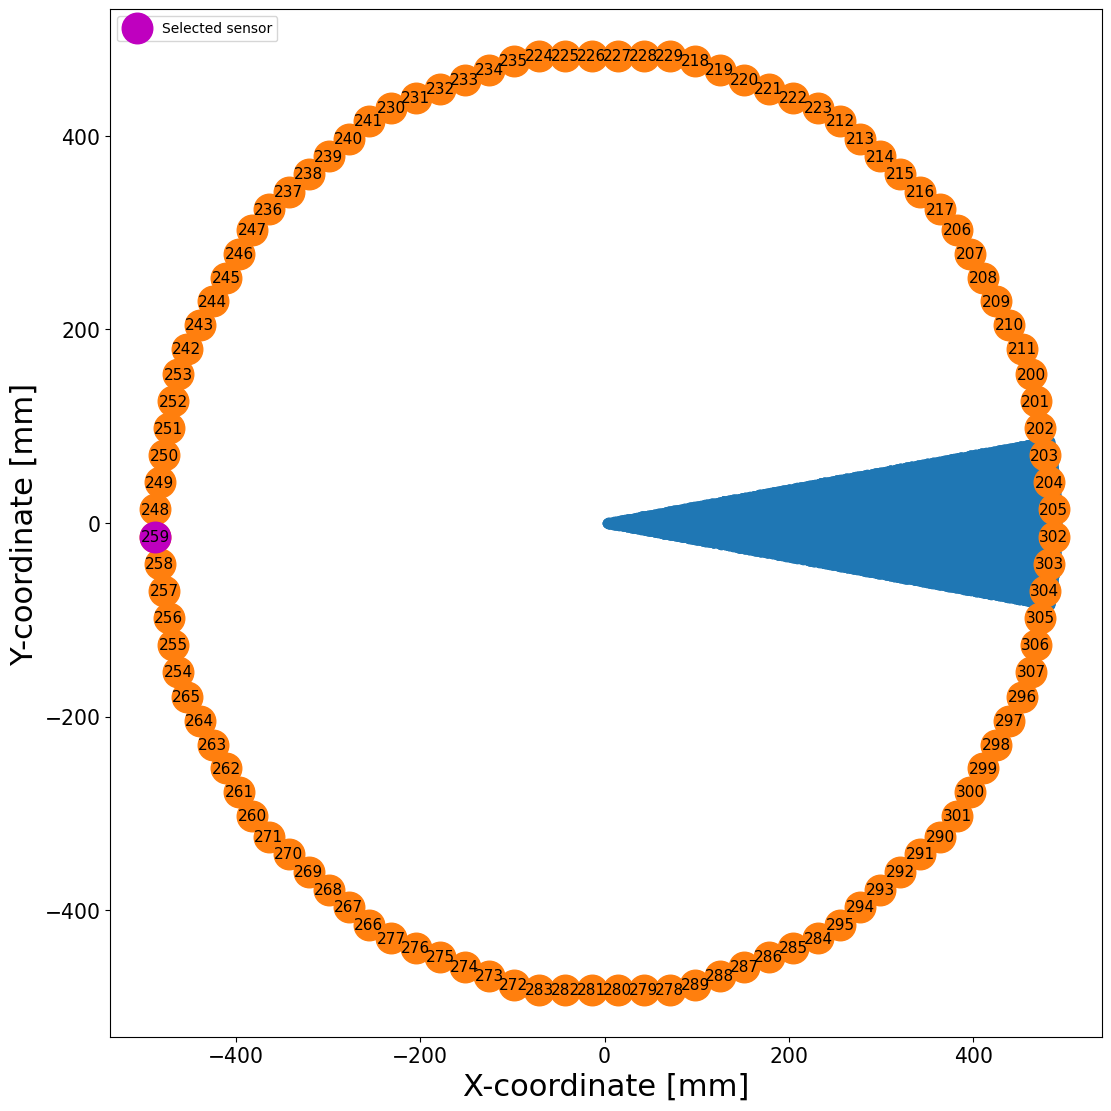

In [52]:
ax = setup.print_sens_geometry(sns_path, sensor)

# Access the figure through the ax object
fig = ax.figure
fig.set_size_inches(11, 11)  # Set new width and height in inches

ax.legend(loc= 'upper left')

In [53]:
# Create TPC
TPC     = s2sim.HPGXeTPC()
TPC.SetDefaults(sns_path)

Default parameters set succesfully :) TPC ready to use


/home/investigator/miniconda3/envs/IC-3.8-2022-04-13/lib/python3.8/site-packages/pandas/io/pytables.py:3523: IncompatibilityWarning: 
where criteria is being ignored as this version [0.0.0] is too old (or
not-defined), read the file in and write it out to a new file to upgrade (with
the copy_to method)

  warnings.warn(ws, IncompatibilityWarning)


In [54]:
s2table = s2sim.s2Table(s2_table_path)

In [55]:
hits = pd.read_hdf(event_path, "/MC/hits")
hits = hits.query(f'event_id == {event}')

In [56]:
particles = pd.read_hdf(event_path, "/MC/particles")
particles = particles.query(f'event_id == {event}')

ie        = particles.query(f'particle_name == "ie-"')

/home/investigator/miniconda3/envs/IC-3.8-2022-04-13/lib/python3.8/site-packages/pandas/io/pytables.py:3523: IncompatibilityWarning: 
where criteria is being ignored as this version [0.0.0] is too old (or
not-defined), read the file in and write it out to a new file to upgrade (with
the copy_to method)

  warnings.warn(ws, IncompatibilityWarning)


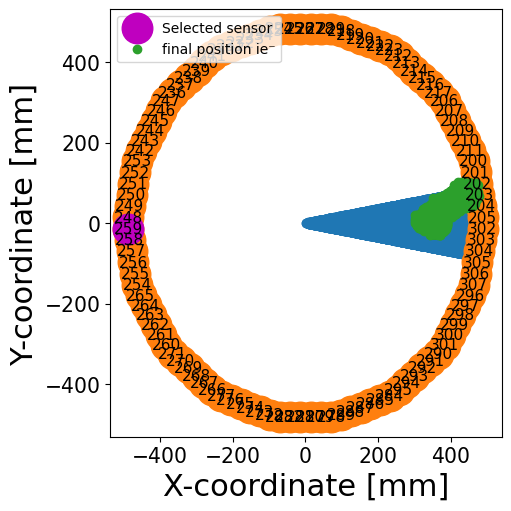

In [57]:
ax = setup.print_sens_geometry(sns_path, sensor)

ax.plot(ie.final_x, ie.final_y, 'o', label = 'final position ie⁻')
# ax.plot(prim_e.final_x, prim_e.final_y, 'o', label = 'final position e⁻')

# Access the figure through the ax object
fig = ax.figure

# Modify the size of the figure
fig.set_size_inches(5, 5)  # Set new width and height in inches

ax.legend(loc= 'upper left')

In [58]:
sns_positions, sns_response = setup.read_fiber_sens(event_path)
sns_response = sns_response.query(f'event_id == {event}')

/home/investigator/miniconda3/envs/IC-3.8-2022-04-13/lib/python3.8/site-packages/pandas/io/pytables.py:3523: IncompatibilityWarning: 
where criteria is being ignored as this version [0.0.0] is too old (or
not-defined), read the file in and write it out to a new file to upgrade (with
the copy_to method)

  warnings.warn(ws, IncompatibilityWarning)


In [59]:
nexusEvent = s2sim.nexusEvent(event_path, event)
nexusEvent.AddDriftAndDiffusion(TPC)

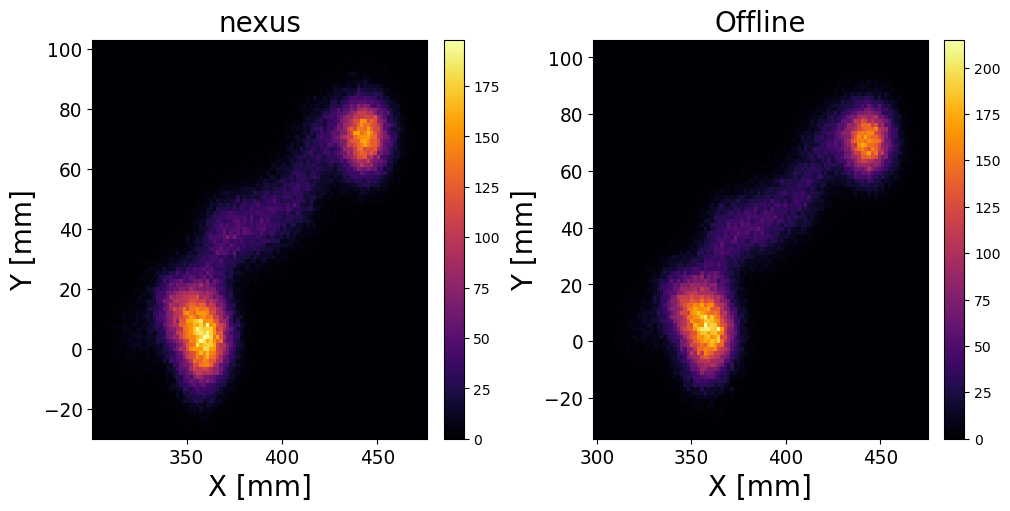

In [60]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,5), constrained_layout=True, sharex=False, sharey=False)

font_size = 20

# nexus
_, _, _, figure_map = ax[0].hist2d(ie.final_x, 
                                   ie.final_y, 
                                   bins = 100, cmap='inferno', label = 'nexus');

fig.colorbar(figure_map, ax = ax[0]);
ax[0].set_title('nexus', fontsize = font_size)

# Offline simulation
_, _, _, figure_map = ax[1].hist2d(nexusEvent.ElectronsFinalX.magnitude, 
                                   nexusEvent.ElectronsFinalY.magnitude, 
                                   bins = 100, cmap='inferno', label = 'nexus');
fig.colorbar(figure_map, ax = ax[1]);
ax[1].set_title('Offline', fontsize = font_size)


for axis in ax:

    axis.set_xlabel('X [mm]', fontsize = font_size);
    axis.set_ylabel('Y [mm]', fontsize = font_size);
    axis.tick_params(axis='both', labelsize = font_size*2/3)
        

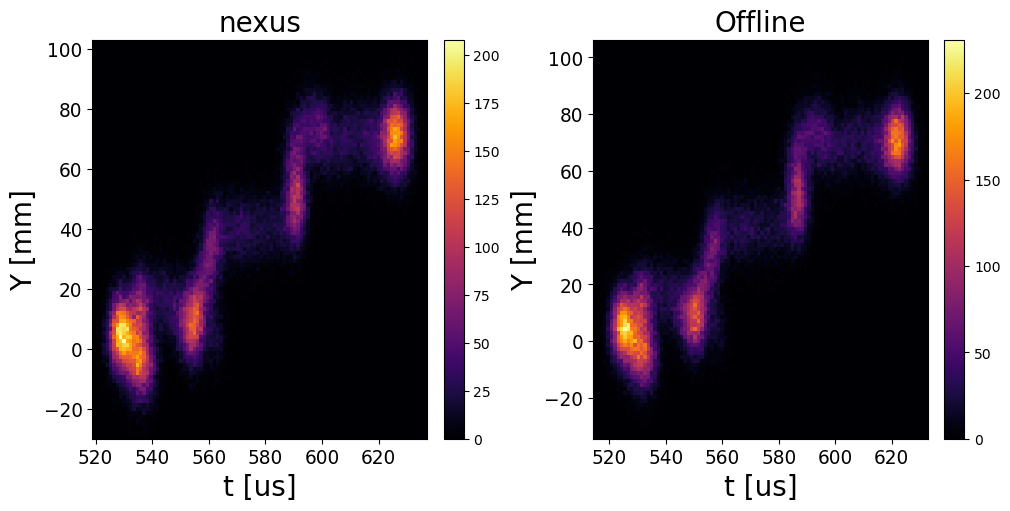

In [61]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,5), constrained_layout=True, sharex=False, sharey=False)

font_size = 20

# nexus
nexus_t = ie.final_t*1e-3 # [us]
_, _, _, figure_map = ax[0].hist2d(nexus_t, 
                                   ie.final_y, 
                                   bins = 100, cmap='inferno', label = 'nexus');

fig.colorbar(figure_map, ax = ax[0]);
ax[0].set_title('nexus', fontsize = font_size)

# Offline simulation
_, _, _, figure_map = ax[1].hist2d(nexusEvent.ElectronsMeasurementTime.to(unit.us).magnitude, 
                                   nexusEvent.ElectronsFinalY.magnitude, 
                                   bins = 100, cmap='inferno', label = 'nexus');
fig.colorbar(figure_map, ax = ax[1]);
ax[1].set_title('Offline', fontsize = font_size)


for axis in ax:

    axis.set_xlabel('t [us]', fontsize = font_size);
    axis.set_ylabel('Y [mm]', fontsize = font_size);
    axis.tick_params(axis='both', labelsize = font_size*2/3)
        

In [62]:
online_signal = sns_response.query(f'sensor_id == {sensor}').copy()
t_binnin = 0.1 # [ns]
online_signal.time_bin = online_signal.time_bin*t_binnin # [ns]


In [63]:
nexus_t = online_signal.time_bin*1e-3 # [us]
nexus_s2 = online_signal.charge # [pes]

In [64]:
online_signal

,event_id,sensor_id,time_bin,charge
10271466,6,259,70.3,1
10271467,6,259,112.0,1
10271468,6,259,113.6,1
10271469,6,259,119.7,1
10271470,6,259,126.6,1
...,...,...,...,...
10280482,6,259,631969.4,1
10280483,6,259,632006.9,1
10280484,6,259,632127.4,1
10280485,6,259,632361.6,1


In [65]:
sns_response

,event_id,sensor_id,time_bin,charge
8938591,6,214,145,1
8938592,6,214,301,1
8938593,6,214,305,1
8938594,6,214,614,1
8938595,6,214,716,1
...,...,...,...,...
10460761,6,212,6320033,1
10460762,6,212,6321650,1
10460763,6,212,6323062,1
10460764,6,212,6348061,1


In [66]:
# %%timeit # (~4mins) (~25s no sé why...)
s2signal = s2sim.s2Signal(s2table, TPC, nexusEvent)


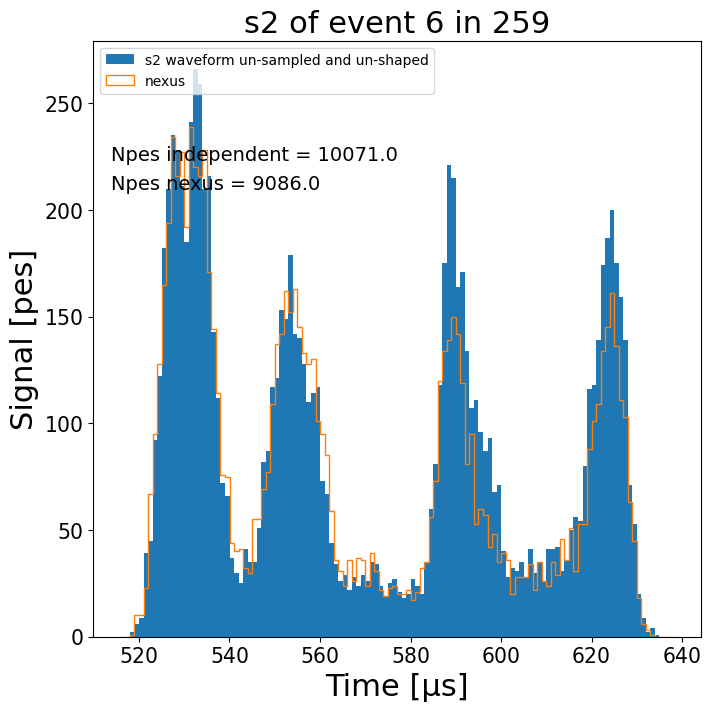

In [67]:

t, waveform, ax = s2signal.PrintWaveform(sensor, bin_width = 1*unit.us, shaped_and_sampled = False)


# nexus_s2 = nexus_s2[nexus_t > 100] # exclude s1
# nexus_t = nexus_t[nexus_t > 100] # exclude s1

# both histograms should have the same binning
bin_width   = 1 *unit.us # [us]
binin       = np.arange(t.magnitude.min() - bin_width.magnitude, t.magnitude.max() + 2*bin_width.magnitude, bin_width.magnitude)


events, bins, bars = ax.hist(nexus_t, binin,
                             weights = nexus_s2,
                             density=False,
                             histtype='step',
                             label = f'nexus'
                            )

# ax.text(0.08, .85, f'Independent reconstruction without recombination and lifetime effects',
# transform=ax.transAxes, fontsize=0.7*font_size, bbox=dict(facecolor='1.', edgecolor='none', pad=3.0))

ax.text(0.03, .8, f'Npes independent = {waveform.sum()}',
transform=ax.transAxes, fontsize=0.7*font_size, bbox=dict(facecolor='1.', edgecolor='none', pad=3.0, alpha = 0))

ax.text(0.03, .75, f'Npes nexus = {events.sum()}',
transform=ax.transAxes, fontsize=0.7*font_size, bbox=dict(facecolor='1.', edgecolor='none', pad=3.0, alpha = 0))

# Add the initial legend
legend = ax.legend()
# Modify the legend labels
new_labels = ['Independent simulation', legend.get_texts()[1].get_text()]
ax.legend(handles=legend.legendHandles, labels=new_labels);

ax.legend(loc = 'upper left');
# ax.set_ylim(0, 500)


In [23]:
s2signal.SensorResponse[sensor].sum(), nexus_s2.sum()

(13052.0, 12925)

In [1]:
# S2 signal script
import sys
sys.path.append('/home/investigator/mariandbt/python/notebooks/modules')

from import_modules import *
import set_up as setup

import s2_simulation as s2sim
from s2_simulation import unit

In [2]:
path = '/home/investigator/mariandbt/python/data'
path = path + '/20240313_s2simulation'

In [3]:
sns_path = os.path.join(path, "ie/20240405_Next100_ie_s2_1.next.h5")
s2_table_path = os.path.join(path, "s2tab/20240405_s2_table.h5")
# event_path = os.path.join(path, "bb/20240228_Next100_10ev_ELon_bb_1.next.h5") # 10 full bb w s2 (ONLY 90 SENSs)
# event_path = os.path.join(path, "bb/20240710_Next100_3ev_ELon_bb_1.next.h5") # 3 full bb w s2
event_path = os.path.join(path, "bb/20240712_Next100_10ev_ELon_bb_1.next.h5") # 10 full bb w s2

# event_path = os.path.join(path, "Kr/20240724_Next100_10ev_ELoff_Kr_1.next.h5") 
# event_path = os.path.join(path, "Kr/20240828_Next100_10ev_ELon_Kr_1.next.h5") 


In [4]:
particles = pd.read_hdf(event_path, "/MC/particles")

In [5]:
# Create TPC
TPC     = s2sim.HPGXeTPC()
TPC.SetDefaults(sns_path)
TPC.SetRecombinationFactor(0)

/home/investigator/miniconda3/envs/IC-3.8-2022-04-13/lib/python3.8/site-packages/pandas/io/pytables.py:3523: IncompatibilityWarning: 
where criteria is being ignored as this version [0.0.0] is too old (or
not-defined), read the file in and write it out to a new file to upgrade (with
the copy_to method)

  warnings.warn(ws, IncompatibilityWarning)


Default parameters set succesfully :) TPC ready to use


In [6]:
s2table = s2sim.s2Table(s2_table_path)

In [7]:
all_hits = pd.read_hdf(event_path, "/MC/hits")


In [8]:
sns_positions, all_sns_response = setup.read_fiber_sens(event_path)


/home/investigator/miniconda3/envs/IC-3.8-2022-04-13/lib/python3.8/site-packages/pandas/io/pytables.py:3523: IncompatibilityWarning: 
where criteria is being ignored as this version [0.0.0] is too old (or
not-defined), read the file in and write it out to a new file to upgrade (with
the copy_to method)

  warnings.warn(ws, IncompatibilityWarning)


In [9]:
all_hits

,event_id,x,y,z,time,energy,label,particle_id,hit_id
0,0,337.609955,14.762523,596.716370,0.003393,0.004316,ACTIVE,2,0
1,0,338.513824,15.014794,597.057739,0.006785,0.009257,ACTIVE,2,1
2,0,339.418762,15.314910,597.354858,0.010179,0.002870,ACTIVE,2,2
3,0,340.342102,15.488117,597.694275,0.013573,0.008995,ACTIVE,2,3
4,0,341.278595,15.667388,597.990662,0.016967,0.003583,ACTIVE,2,4
...,...,...,...,...,...,...,...,...,...
7655,9,107.124641,27.791233,602.239075,0.306379,0.000356,ACTIVE,1,141
7656,9,107.125420,27.791782,602.238831,0.306411,0.000271,ACTIVE,1,142
7657,9,107.126099,27.791512,602.238831,0.306436,0.000451,ACTIVE,1,143
7658,9,107.126595,27.791212,602.238770,0.306458,0.000309,ACTIVE,1,144


In [10]:
all_hits[all_hits.x**2 + all_hits.y**2 >= 460**2]

,event_id,x,y,z,time,energy,label,particle_id,hit_id
2187,2,460.174469,7.161661,623.672119,0.584590,0.002637,ACTIVE,1,169
2188,2,460.669830,7.994670,623.811279,0.588328,0.008033,ACTIVE,1,170
2189,2,461.142029,8.825304,624.048645,0.592097,0.005655,ACTIVE,1,171
2190,2,461.981262,9.316357,624.265320,0.595916,0.004896,ACTIVE,1,172
2191,2,462.862701,9.288055,624.607117,0.599548,0.004151,ACTIVE,1,173
2192,2,463.566498,8.782843,625.096313,0.603374,0.004215,ACTIVE,1,174
2193,2,463.879791,8.289705,625.905884,0.607218,0.005639,ACTIVE,1,175
2194,2,464.038910,7.729159,626.712646,0.611057,0.007015,ACTIVE,1,176
2195,2,464.119263,7.227058,627.569763,0.614910,0.004748,ACTIVE,1,177
2196,2,463.632446,6.501141,627.435974,0.618335,0.004649,ACTIVE,1,178


In [11]:
(sns_positions.x**2 + sns_positions.y**2).min(), 490**2

(233063.828125, 240100)

In [12]:
t_binnin = 0.1 # [ns]
nexus_vs_indepe_dict = {}


for ev in all_hits.event_id.unique()[:]:
    
    event = ev
    nexus_vs_indepe_dict[event] = {}
        
    sns_response = all_sns_response.copy().query(f'event_id == {event}')       

    nexusEvent = s2sim.nexusEvent(event_path, event)
    nexusEvent.AddDriftAndDiffusion(TPC)
    
    s2signal = s2sim.s2Signal(s2table, TPC, nexusEvent)
    
    
    for sns in sns_positions.sensor_id:
        
        sensor = sns
        
        online_signal = sns_response.query(f'sensor_id == {sensor}').copy()
        online_signal.time_bin = online_signal.time_bin*t_binnin # [ns]
        
        nexus_s2 = online_signal.charge # [pes]
        npes_nexus = nexus_s2.sum()
        
        npes_indepe = s2signal.SensorResponse[sensor].sum()
        
        nexus_vs_indepe_dict[event][sensor] = (npes_nexus - npes_indepe)/npes_nexus 
        

        print(f'{event}, {sensor}                                       ', end = '\r')
        
    print('\n')
    

0, 237                                       . Signal created succesfully :)                

1, 237                                       . Signal created succesfully :)                

2, 237                                       . Signal created succesfully :)                

3, 237                                       . Signal created succesfully :)                

4, 237                                       . Signal created succesfully :)                

5, 237                                       . Signal created succesfully :)                

6, 237                                       . Signal created succesfully :)                

7, 237                                       . Signal created succesfully :)                

8, 237                                       . Signal created succesfully :)                

9, 237                                       . Signal created succesfully :)                



In [13]:
nexus_vs_indepe_dict[0][255]

-0.03804981452040276

In [14]:
list(nexus_vs_indepe_dict[0].values()) > np.array([0])

array([False, False, False, False, False, False, False, False, False,
        True, False, False,  True,  True, False, False, False,  True,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False,  True, False, False,  True, False, False,
       False, False, False,  True, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
        True,  True,  True, False,  True, False, False, False, False,
       False, False, False, False, False, False,  True, False,  True,
       False, False,  True, False, False, False, False,  True,  True,
        True, False, False,  True,  True, False, False, False, False,
       False,  True, False, False, False, False, False, False, False])

In [15]:
# mask = list(nexus_vs_indepe_dict[0].values()) == min(nexus_vs_indepe_dict[0].values())
# mask = list(nexus_vs_indepe_dict[6].values()) > np.array([6e3])
mask = list(nexus_vs_indepe_dict[8].values()) == min(nexus_vs_indepe_dict[8].values())
mask = list(nexus_vs_indepe_dict[8].values()) == max(nexus_vs_indepe_dict[8].values())
keys = np.array(list(nexus_vs_indepe_dict[8].keys()))


In [16]:
max(nexus_vs_indepe_dict[8].values())

0.019070583077597545

In [17]:
nexus_vs_indepe_dict[8][288]

-0.023414836303356817

In [18]:
TPC.RecombinationFactor

0

In [19]:
keys[mask]

array([218])

(-8.0, 16.0)

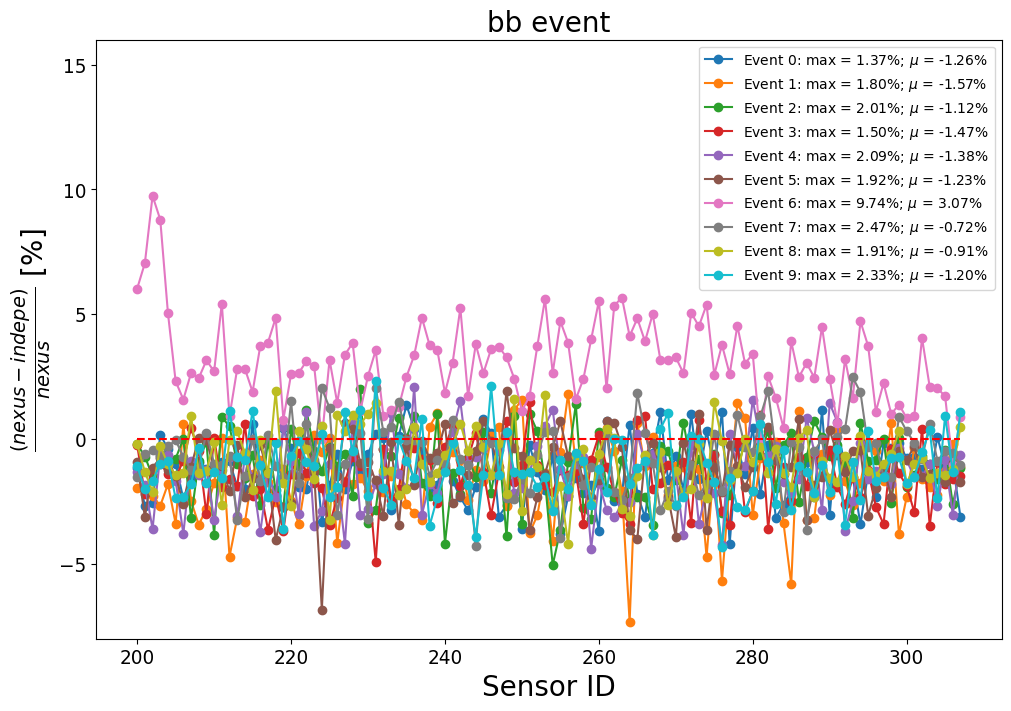

In [26]:
# FIDUCIAL RADIO NOT APPLYING !!!!!!!!!!!!!!!!!!!!!!!!!lol
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,7), constrained_layout=True, sharex=False, sharey=False)

font_size = 20

bot_ev = None
top_ev = None

for event in list(nexus_vs_indepe_dict.keys())[bot_ev:top_ev]:
    
    event_dict = nexus_vs_indepe_dict[event]
    
    # Sort dictionary items by keys directly
    sorted_items = sorted(event_dict.items())  # Returns a list of tuples sorted by keys

    # Unpack sorted keys and values
    sorted_keys, sorted_values = zip(*sorted_items)
    
    sorted_values_percent = np.array(sorted_values)*100
    
    ax.plot(sorted_keys, sorted_values_percent, 'o-', 
            label = fr'Event {event}: max = {max(sorted_values_percent):.2f}%; $\mu$ = {np.mean(sorted_values_percent):.2f}%')


ax.plot(sorted_keys, np.zeros(len(sorted_keys)), '--r')    

# ax.set_title('Kr event', fontsize = font_size);
ax.set_title('bb event', fontsize = font_size);
ax.set_xlabel('Sensor ID', fontsize = font_size);
ax.set_ylabel(r'$\frac{(nexus - indepe)}{nexus}$ [%]', fontsize = font_size);
ax.tick_params(axis='both', labelsize = font_size*2/3)
ax.legend(loc = 'best')

ax.set_ylim(-8, 16)


In [21]:
from matplotlib.colors import ListedColormap, TwoSlopeNorm

In [19]:
event = 8

particulites = particles.copy().query(f'event_id == {event}')
ie        = particulites.query(f'particle_name == "ie-"')
prim_e    = particulites.query(f'primary == {1}')

In [20]:
particulites

,event_id,particle_id,particle_name,primary,mother_id,initial_x,initial_y,initial_z,initial_t,final_x,...,initial_momentum_x,initial_momentum_y,initial_momentum_z,final_momentum_x,final_momentum_y,final_momentum_z,kin_energy,length,creator_proc,final_proc
814816,8,142,ie-,0,2,377.914307,-35.195988,596.684875,0.002090,376.963867,...,0.0,0.0,0.001011,0.0,0.0,0.001011,0.000001,11.1,Clustering,Drift
814817,8,141,ie-,0,2,377.736694,-35.259136,596.772522,0.002795,373.058716,...,0.0,0.0,0.001011,0.0,0.0,0.001011,0.000001,11.1,Clustering,Drift
814818,8,140,ie-,0,2,378.432526,-35.011745,596.429199,0.000034,358.571014,...,0.0,0.0,0.001011,0.0,0.0,0.001011,0.000001,11.1,Clustering,Drift
814819,8,139,ie-,0,2,377.791626,-35.239601,596.745422,0.002577,386.199799,...,0.0,0.0,0.001011,0.0,0.0,0.001011,0.000001,11.1,Clustering,Drift
814820,8,138,ie-,0,2,377.889496,-35.204815,596.697144,0.002188,383.217072,...,0.0,0.0,0.001011,0.0,0.0,0.001011,0.000001,11.1,Clustering,Drift
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
924656,8,207840311,ie-,0,1,376.943756,-35.078773,596.256775,0.035933,381.608154,...,0.0,0.0,0.001011,0.0,0.0,0.001011,0.000001,11.1,Clustering,Drift
924657,8,207840310,ie-,0,1,376.944092,-35.077461,596.257324,0.035981,384.892792,...,0.0,0.0,0.001011,0.0,0.0,0.001011,0.000001,11.1,Clustering,Drift
924658,8,207840309,ie-,0,1,376.943970,-35.077976,596.257141,0.035962,378.650757,...,0.0,0.0,0.001011,0.0,0.0,0.001011,0.000001,11.1,Clustering,Drift
924659,8,207840308,ie-,0,1,376.943756,-35.078857,596.256714,0.035929,384.547333,...,0.0,0.0,0.001011,0.0,0.0,0.001011,0.000001,11.1,Clustering,Drift


In [21]:
prim_e

,event_id,particle_id,particle_name,primary,mother_id,initial_x,initial_y,initial_z,initial_t,final_x,...,initial_momentum_x,initial_momentum_y,initial_momentum_z,final_momentum_x,final_momentum_y,final_momentum_z,kin_energy,length,creator_proc,final_proc
920039,8,2,e-,1,0,378.44104,-35.008724,596.424988,0.0,416.478668,...,-2.302003,-1.016387,1.272401,0.0,0.0,-0.0,2.354727,252.715500,none,NoProcess
924539,8,1,e-,1,0,378.44104,-35.008724,596.424988,0.0,376.944153,...,0.148445,0.232433,-0.199851,0.0,0.0,0.0,0.103103,5.099377,none,NoProcess


In [22]:
counts.min()

NameError: name 'counts' is not defined

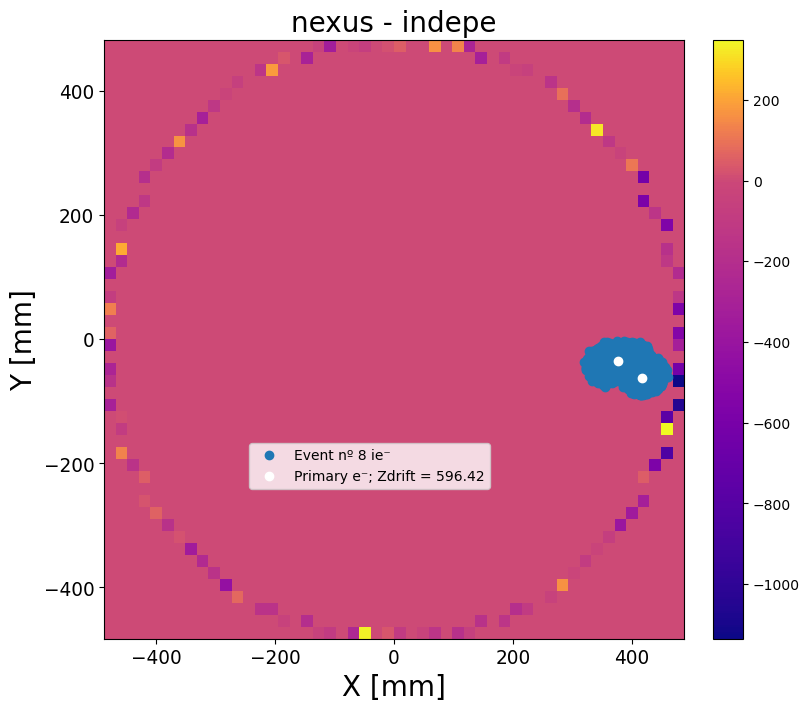

In [23]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,7), constrained_layout=True, sharex=False, sharey=False)

font_size = 20

event_dict = nexus_vs_indepe_dict[event]
    
# Sort dictionary items by keys directly
sorted_items = sorted(event_dict.items())  # Returns a list of tuples sorted by keys

# Unpack sorted keys and values
sorted_keys, sorted_values = zip(*sorted_items)

# Use sorted_keys to filter and sort the DataFrame
sorted_df = sns_positions.set_index('sensor_id').loc[list(sorted_keys)]
sens_x = sorted_df.x.to_numpy()
sens_y = sorted_df.y.to_numpy()

# map
# Define the colormap with white for the minimum value
cmap = plt.cm.plasma  # Using the viridis colormap as an example
cmap_colors = cmap(np.arange(cmap.N))
# cmap_colors[0] = [1, 1, 1, 1]  # Set the lowest value to white
custom_cmap = ListedColormap(cmap_colors)


counts, _, _, figure_map = ax.hist2d(sens_x, sens_y, 
                                     weights = sorted_values,
                                     bins = 50, cmap=custom_cmap, label = 'nexus - indepe');

# Create a normalizer centered around 0
norm = TwoSlopeNorm(vmin=counts.min(), vcenter=counts.mean(), vmax=counts.max())
# norm = TwoSlopeNorm(vmin=-3e4, vcenter=0, vmax=1e4)

# Apply normalization to the colormap
figure_map.set_norm(norm)


fig.colorbar(figure_map, ax = ax);
ax.set_title('nexus - indepe', fontsize = font_size)

ax.plot(ie.final_x, ie.final_y, 'o', label = f'Event nº {event} ie⁻')
ax.plot(prim_e.final_x, prim_e.final_y, 'ow', label = f'Primary e⁻; Zdrift = {prim_e.initial_z.mean():.2f}')

ax.set_xlabel('X [mm]', fontsize = font_size);
ax.set_ylabel('Y [mm]', fontsize = font_size);
ax.tick_params(axis='both', labelsize = font_size*2/3)

ax.legend(loc = (0.25, 0.25))


In [67]:
z_drift_dict.values()

dict_values([(-218.0, 67.0), (-54.0, 67.0), (-72.0, 108.0), (-538.0, 83.0), (-1185.0, 721.0), (-287.0, 104.0), (-382.0, 243.0), (-610.0, 161.0), (-111.0, 60.0), (-205.0, 53.0)])

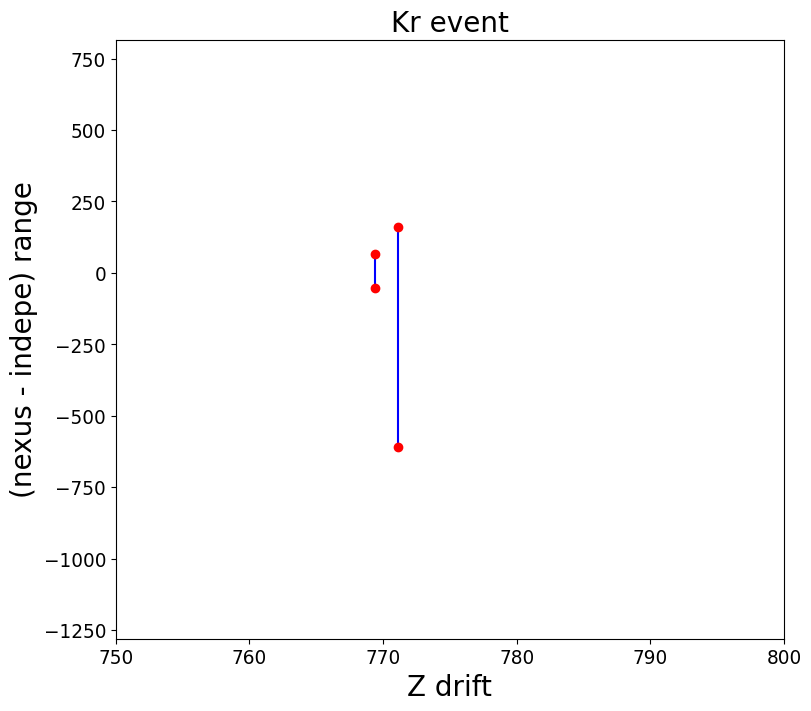

In [77]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,7), constrained_layout=True, sharex=False, sharey=False)

font_size = 20

z_drift_dict = {}

bot_ev = None
top_ev = None

for event in list(nexus_vs_indepe_dict.keys())[bot_ev:top_ev]:
    event_dict_min = min(nexus_vs_indepe_dict[event].values())
    event_dict_max = max(nexus_vs_indepe_dict[event].values())

    particulites = particles.copy().query(f'event_id == {event}')
    z_drift = particulites.query(f'primary == {1}').initial_z.mean()
    
    z_drift_dict[z_drift] = (event_dict_min, event_dict_max)

# Plot vertical lines for each z_drift showing the range (min to max)
for z_drift, (y_min, y_max) in z_drift_dict.items():
    ax.vlines(x=z_drift, ymin=y_min, ymax=y_max, color='blue', linestyle='-')
    ax.plot(z_drift, y_min, 'o', color='red')  # Plot the min value as a point
    ax.plot(z_drift, y_max, 'o', color='red')   # Plot the max value as a point

ax.set_title('Kr event', fontsize=font_size)
ax.set_xlabel('Z drift', fontsize=font_size)
ax.set_ylabel('(nexus - indepe) range', fontsize=font_size)
ax.tick_params(axis='both', labelsize=font_size*2/3)
# ax.legend(loc='best')
ax.set_xlim(750, 800)

plt.show()


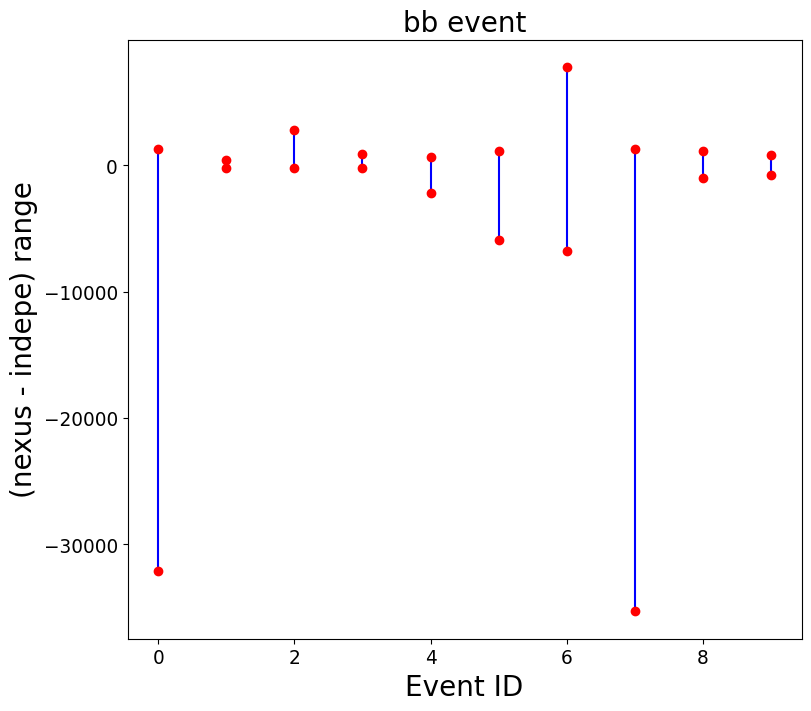

In [16]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,7), constrained_layout=True, sharex=False, sharey=False)

font_size = 20

event_dict = {}

bot_ev = None
top_ev = None

for event in list(nexus_vs_indepe_dict.keys())[bot_ev:top_ev]:
    event_dict_min = min(nexus_vs_indepe_dict[event].values())
    event_dict_max = max(nexus_vs_indepe_dict[event].values())

    event_dict[event] = (event_dict_min, event_dict_max)

# Plot vertical lines for each z_drift showing the range (min to max)
for event, (y_min, y_max) in event_dict.items():
    ax.vlines(x=event, ymin=y_min, ymax=y_max, color='blue', linestyle='-')
    ax.plot(event, y_min, 'o', color='red')  # Plot the min value as a point
    ax.plot(event, y_max, 'o', color='red')   # Plot the max value as a point

ax.set_title('bb event', fontsize=font_size)
ax.set_xlabel('Event ID', fontsize=font_size)
ax.set_ylabel('(nexus - indepe) range', fontsize=font_size)
ax.tick_params(axis='both', labelsize=font_size*2/3)
# ax.legend(loc='best')
# ax.set_xlim(750, 800)

plt.show()


# $\beta$ $\beta$ waveform + diff: nexus vs offline STEP BY STEP

In [1]:
# S2 signal script
import sys
sys.path.append('/home/investigator/mariandbt/python/notebooks/modules')

from import_modules import *
import set_up as setup

import s2_simulation as s2sim
from s2_simulation import unit

In [2]:
path = '/home/investigator/mariandbt/python/data'
path = path + '/20240313_s2simulation'

In [3]:
sns_path = os.path.join(path, "ie/20240405_Next100_ie_s2_1.next.h5")
s2_table_path = os.path.join(path, "s2tab/20240405_s2_table.h5")
# event_path = os.path.join(path, "bb/20240228_Next100_10ev_ELon_bb_1.next.h5") # 10 full bb w s2 (ONLY 90 SENSs)
# event_path = os.path.join(path, "bb/20240710_Next100_3ev_ELon_bb_1.next.h5") # 3 full bb w s2
event_path = os.path.join(path, "bb/20240712_Next100_10ev_ELon_bb_1.next.h5") # 10 full bb w s2

# event_path = os.path.join(path, "Kr/20240724_Next100_10ev_ELoff_Kr_1.next.h5") 
# event_path = os.path.join(path, "Kr/20240828_Next100_10ev_ELon_Kr_1.next.h5") 


In [4]:
particles = pd.read_hdf(event_path, "/MC/particles")

In [5]:
hits = pd.read_hdf(event_path, "/MC/hits")


In [6]:
# Create TPC
TPC     = s2sim.HPGXeTPC()
TPC.SetDefaults(sns_path)

/home/investigator/miniconda3/envs/IC-3.8-2022-04-13/lib/python3.8/site-packages/pandas/io/pytables.py:3523: IncompatibilityWarning: 
where criteria is being ignored as this version [0.0.0] is too old (or
not-defined), read the file in and write it out to a new file to upgrade (with
the copy_to method)

  warnings.warn(ws, IncompatibilityWarning)


Default parameters set succesfully :) TPC ready to use


In [7]:
s2table = s2sim.s2Table(s2_table_path)
s2table.BuildS2TablesDict()


In [8]:
sns_positions, sns_response = setup.read_fiber_sens(event_path)


/home/investigator/miniconda3/envs/IC-3.8-2022-04-13/lib/python3.8/site-packages/pandas/io/pytables.py:3523: IncompatibilityWarning: 
where criteria is being ignored as this version [0.0.0] is too old (or
not-defined), read the file in and write it out to a new file to upgrade (with
the copy_to method)

  warnings.warn(ws, IncompatibilityWarning)


In [9]:
sns_response.groupby('event_id').sum()

,sensor_id,time_bin,charge
event_id,,,
0,382832020,10832452988838,1576259
1,286541908,6681842512342,1151186
2,369046357,8918906217097,1537820
3,390433384,9314362322971,1571982
4,361059116,8730458322061,1461027
5,398114609,9728721661332,1568691
6,378335254,8626748001146,1555113
7,284167678,6539020181133,1201171
8,397927422,9463681495546,1568609


In [10]:
event, sensor = 0, 255

In [11]:
nexusEvent = s2sim.nexusEvent(event_path, event)
nexusEvent.AddDriftAndDiffusion(TPC)

In [12]:
time_data   = nexusEvent.ElectronsMeasurementTime
t_delay     = (nexusEvent.ElectronsFinalZ + TPC.HalfWidthEL)/TPC.DriftVelocityEL 
t_delay     = t_delay.to(unit.ns)
time_data   = (time_data + t_delay).to(unit.ns) # [ns]
t_values    = time_data.magnitude.astype(np.float32)

In [13]:
Time   = t_values *unit.ns# [ns]

In [14]:
Time

Magnitude,[602921.6875 597138.875 598236.375 ... 594470.9375 593747.0 594448.75]
Units,nanosecond


In [15]:
x_dict      = dict(zip(TPC.SensorsIDs, TPC.SensorX.magnitude))
y_dict      = dict(zip(TPC.SensorsIDs, TPC.SensorY.magnitude))

sensor_id_sorted_by_theta   = TPC.SensorsIDs[np.argsort(TPC.SensorTheta.magnitude)]
pos_to_id_dict              = dict(zip(TPC.SensorsPosID,  sensor_id_sorted_by_theta))
id_to_pos_dict              = dict(zip(sensor_id_sorted_by_theta,  TPC.SensorsPosID))

In [23]:
id_to_pos_dict

{259: 0,
 258: 1,
 257: 2,
 256: 3,
 255: 4,
 254: 5,
 265: 6,
 264: 7,
 263: 8,
 262: 9,
 261: 10,
 260: 11,
 271: 12,
 270: 13,
 269: 14,
 268: 15,
 267: 16,
 266: 17,
 277: 18,
 276: 19,
 275: 20,
 274: 21,
 273: 22,
 272: 23,
 283: 24,
 282: 25,
 281: 26,
 280: 27,
 279: 28,
 278: 29,
 289: 30,
 288: 31,
 287: 32,
 286: 33,
 285: 34,
 284: 35,
 295: 36,
 294: 37,
 293: 38,
 292: 39,
 291: 40,
 290: 41,
 301: 42,
 300: 43,
 299: 44,
 298: 45,
 297: 46,
 296: 47,
 307: 48,
 306: 49,
 305: 50,
 304: 51,
 303: 52,
 302: 53,
 205: 54,
 204: 55,
 203: 56,
 202: 57,
 201: 58,
 200: 59,
 211: 60,
 210: 61,
 209: 62,
 208: 63,
 207: 64,
 206: 65,
 217: 66,
 216: 67,
 215: 68,
 214: 69,
 213: 70,
 212: 71,
 223: 72,
 222: 73,
 221: 74,
 220: 75,
 219: 76,
 218: 77,
 229: 78,
 228: 79,
 227: 80,
 226: 81,
 225: 82,
 224: 83,
 235: 84,
 234: 85,
 233: 86,
 232: 87,
 231: 88,
 230: 89,
 241: 90,
 240: 91,
 239: 92,
 238: 93,
 237: 94,
 236: 95,
 247: 96,
 246: 97,
 245: 98,
 244: 99,
 243: 100,

In [16]:
rotation

NameError: name 'rotation' is not defined

In [18]:
sns_positions.loc[sns_positions.sensor_id == 298]

,sensor_id,sensor_name,x,y,z
76,298,F_SENSOR,424.991638,-229.010788,8.225


In [19]:

ie = particles.query(f'event_id == {event}')
ie = ie.query(f'particle_name == "ie-"')


In [20]:
final_alpha = np.arctan2(ie.final_y, ie.final_x)

In [21]:
rotation_nexev = s2sim.FindRotation(nexusEvent.ElectronsFinalAlpha.magnitude, TPC)
rotation_parts = s2sim.FindRotation(final_alpha, TPC)

In [24]:
rotation    = s2sim.FindRotation(nexusEvent.ElectronsFinalAlpha.magnitude, TPC)

new_alpha   = nexusEvent.ElectronsFinalAlpha - rotation * TPC.DeltaTheta
new_xx      = nexusEvent.ElectronsFinalR * np.cos(new_alpha)
new_yy      = nexusEvent.ElectronsFinalR * np.sin(new_alpha)

# new_sens_id     = s2sim.FindSensor(sensor, rotation, TPC)

In [88]:
np.unique(new_sens_id) # AQUIIII EL ERROOOOOOOOR!!!!!!!!!!!! tendría que ser 255 ->

array([255, 303], dtype=uint32)

/home/investigator/miniconda3/envs/IC-3.8-2022-04-13/lib/python3.8/site-packages/pandas/io/pytables.py:3523: IncompatibilityWarning: 
where criteria is being ignored as this version [0.0.0] is too old (or
not-defined), read the file in and write it out to a new file to upgrade (with
the copy_to method)

  warnings.warn(ws, IncompatibilityWarning)


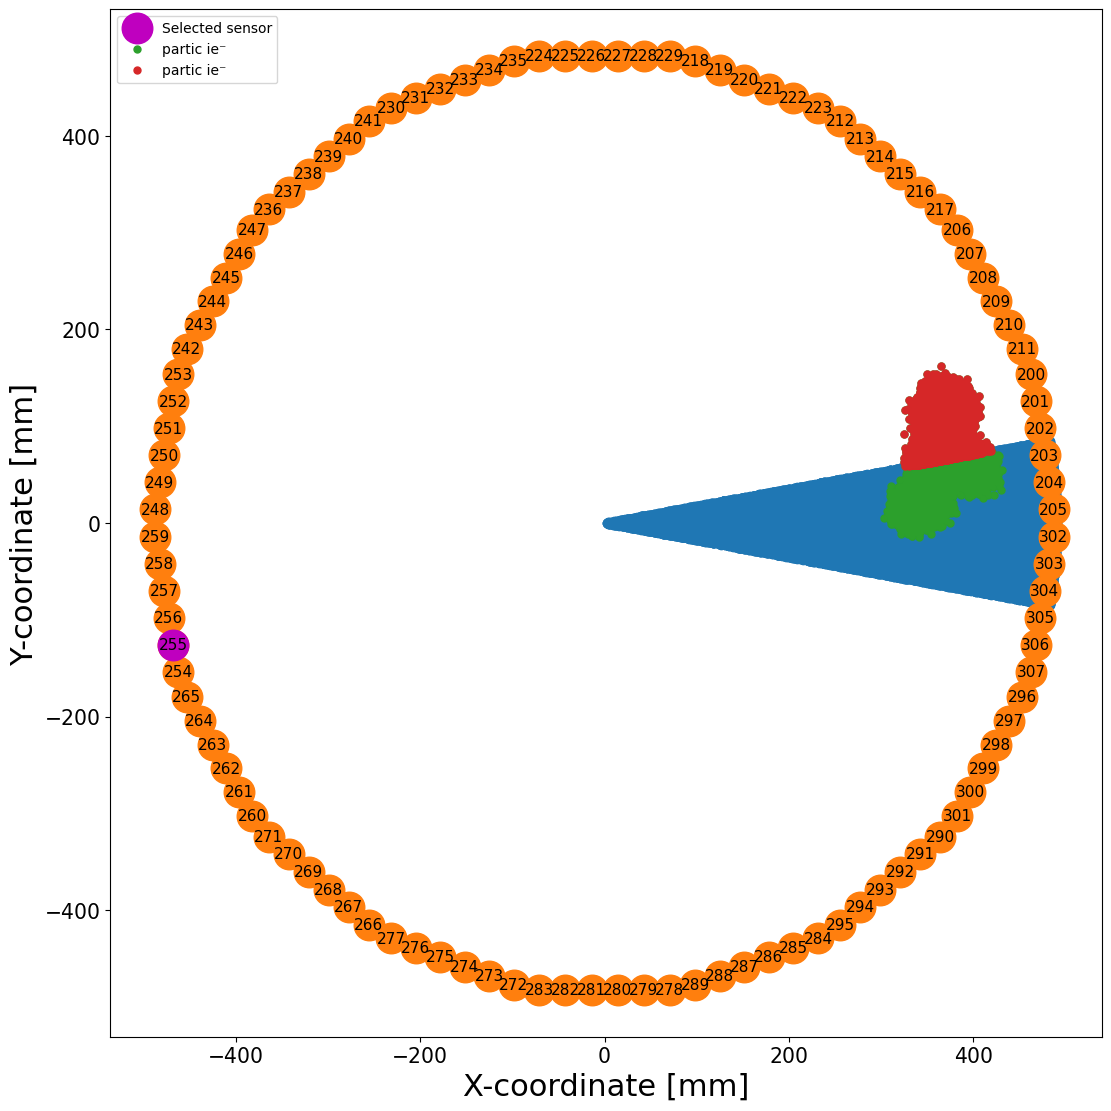

In [80]:
ax = setup.print_sens_geometry(sns_path, sensor)

marker_size = 5

# ax.plot(ie.final_x, ie.final_y, 'o', label = 'final position ie⁻', markersize = marker_size)

# ie_id = 185242263
# ax.plot(ie.final_x[ie.particle_id == ie_id], ie.final_y[ie.particle_id == ie_id], 'o', label = 'ie⁻', markersize = marker_size)
# ax.plot(rotated_ie.final_x, rotated_ie.final_y, 'o', label = 'partic ie⁻', markersize = marker_size)

ax.plot(nexusEvent.ElectronsFinalX.magnitude, nexusEvent.ElectronsFinalY.magnitude, 'o', label = 'partic ie⁻', markersize = marker_size)
ax.plot(nexusEvent.ElectronsFinalX.magnitude[rotation_nexev != 0], nexusEvent.ElectronsFinalY.magnitude[rotation_nexev != 0], 'o', label = 'partic ie⁻', markersize = marker_size)


# Access the figure through the ax object
fig = ax.figure
fig.set_size_inches(11, 11)  # Set new width and height in inches

ax.legend(loc= 'upper left')

In [26]:
sensor_id_sorted_by_theta

array([259, 258, 257, 256, 255, 254, 265, 264, 263, 262, 261, 260, 271,
       270, 269, 268, 267, 266, 277, 276, 275, 274, 273, 272, 283, 282,
       281, 280, 279, 278, 289, 288, 287, 286, 285, 284, 295, 294, 293,
       292, 291, 290, 301, 300, 299, 298, 297, 296, 307, 306, 305, 304,
       303, 302, 205, 204, 203, 202, 201, 200, 211, 210, 209, 208, 207,
       206, 217, 216, 215, 214, 213, 212, 223, 222, 221, 220, 219, 218,
       229, 228, 227, 226, 225, 224, 235, 234, 233, 232, 231, 230, 241,
       240, 239, 238, 237, 236, 247, 246, 245, 244, 243, 242, 253, 252,
       251, 250, 249, 248], dtype=uint32)

In [90]:
sensor_id_sorted_by_theta

array([259, 258, 257, 256, 255, 254, 265, 264, 263, 262, 261, 260, 271,
       270, 269, 268, 267, 266, 277, 276, 275, 274, 273, 272, 283, 282,
       281, 280, 279, 278, 289, 288, 287, 286, 285, 284, 295, 294, 293,
       292, 291, 290, 301, 300, 299, 298, 297, 296, 307, 306, 305, 304,
       303, 302, 205, 204, 203, 202, 201, 200, 211, 210, 209, 208, 207,
       206, 217, 216, 215, 214, 213, 212, 223, 222, 221, 220, 219, 218,
       229, 228, 227, 226, 225, 224, 235, 234, 233, 232, 231, 230, 241,
       240, 239, 238, 237, 236, 247, 246, 245, 244, 243, 242, 253, 252,
       251, 250, 249, 248], dtype=uint32)

In [37]:
id_to_pos_dict

{259: 0,
 258: 1,
 257: 2,
 256: 3,
 255: 4,
 254: 5,
 265: 6,
 264: 7,
 263: 8,
 262: 9,
 261: 10,
 260: 11,
 271: 12,
 270: 13,
 269: 14,
 268: 15,
 267: 16,
 266: 17,
 277: 18,
 276: 19,
 275: 20,
 274: 21,
 273: 22,
 272: 23,
 283: 24,
 282: 25,
 281: 26,
 280: 27,
 279: 28,
 278: 29,
 289: 30,
 288: 31,
 287: 32,
 286: 33,
 285: 34,
 284: 35,
 295: 36,
 294: 37,
 293: 38,
 292: 39,
 291: 40,
 290: 41,
 301: 42,
 300: 43,
 299: 44,
 298: 45,
 297: 46,
 296: 47,
 307: 48,
 306: 49,
 305: 50,
 304: 51,
 303: 52,
 302: 53,
 205: 54,
 204: 55,
 203: 56,
 202: 57,
 201: 58,
 200: 59,
 211: 60,
 210: 61,
 209: 62,
 208: 63,
 207: 64,
 206: 65,
 217: 66,
 216: 67,
 215: 68,
 214: 69,
 213: 70,
 212: 71,
 223: 72,
 222: 73,
 221: 74,
 220: 75,
 219: 76,
 218: 77,
 229: 78,
 228: 79,
 227: 80,
 226: 81,
 225: 82,
 224: 83,
 235: 84,
 234: 85,
 233: 86,
 232: 87,
 231: 88,
 230: 89,
 241: 90,
 240: 91,
 239: 92,
 238: 93,
 237: 94,
 236: 95,
 247: 96,
 246: 97,
 245: 98,
 244: 99,
 243: 100,

In [96]:
id_to_pos_dict.values()

dict_values([-54.0, -53.0, -52.0, -51.0, -50.0, -49.0, -48.0, -47.0, -46.0, -45.0, -44.0, -43.0, -42.0, -41.0, -40.0, -39.0, -38.0, -37.0, -36.0, -35.0, -34.0, -33.0, -32.0, -31.0, -30.0, -29.0, -28.0, -27.0, -26.0, -25.0, -24.0, -23.0, -22.0, -21.0, -20.0, -19.0, -18.0, -17.0, -16.0, -15.0, -14.0, -13.0, -12.0, -11.0, -10.0, -9.0, -8.0, -7.0, -6.0, -5.0, -4.0, -3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0])

In [97]:
pos, id_to_pos_dict[255], pos - rotation*TPC.SensorsPerPanel, new_pos

(-50.0, -50.0, -56.0, -2.0)

In [28]:

min_pos, max_pos 

(0, 107)

In [171]:
np.arange(8)

array([0, 1, 2, 3, 4, 5, 6, 7])

In [106]:
TPC.NSensors/2 # !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! ERROR FINDING THE CORRECT SENSOR

54.0

In [51]:
110%108

2

In [58]:
pos     = id_to_pos_dict[255]
rotation = 1
max_pos = max(id_to_pos_dict.values()) + 1

print(pos)
new_pos = pos - rotation*TPC.SensorsPerPanel
print(new_pos)

if (new_pos == max_pos):
    new_pos = 0
    print('border ', new_pos)

else:
    new_pos = new_pos%(max_pos)

new_sens_id = pos_to_id_dict[new_pos]

4
-2


In [59]:
new_pos, new_sens_id

(106, 249)

In [18]:
s2_data     = s2sim.FindS2(sensor, nexusEvent, s2table, TPC)
s2_values   = s2_data.astype(np.float32) # [pes]

NameError: name 'id_to_pos_dict' is not defined

In [ ]:
s2signal = s2sim.s2Signal(s2table, TPC, nexusEvent)

In [ ]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize=(7, 7), constrained_layout=True) # Create a new figure


